### Semantic Classification of Hong Kong's Doctor Reviews
This notebook is designed to utilize machine learning algorithms for the semantic classification of doctor reviews in Hong Kong. The dataset used in this project was collected through a web crawler from the doctor review website seedoctor.com.hk.



In [1]:
!pip install -q -U keras-tuner
# Import required libraries
import pandas as pd
import os
from google.colab import drive
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from keras.models import Sequential
from keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, Input, Embedding, BatchNormalization, Activation
import keras_tuner as kt
import sklearn
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score, confusion_matrix
import numpy as np
from tqdm import tqdm
import torch
import numpy as np
from transformers import BertTokenizer, BertModel
import gc
import math
import time
from typing import Callable


# Mount the google drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.1 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
# Download Chinese font for ploting figure
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta',
              weight = 18)

--2025-04-22 09:54:32--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.251.175.113, 142.251.175.101, 142.251.175.102, ...
Connecting to drive.google.com (drive.google.com)|142.251.175.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-04-22 09:54:32--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.4.132, 2404:6800:4003:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.4.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  98.2MB/s    in 0.2s    

2025-04-22 09:5

In [ ]:
# Get the current working directory and read the data set
cwd = os.getcwd()
data = pd.read_csv(cwd + "/drive/MyDrive/Colab Notebooks/Project/clean_data.csv") # Change the path to dataset if necessary

### Part 1 - Preprocessing the Dataset

In this section, we will explore the dataset and perform essential preprocessing steps. The preprocessing includes:

1. **Handling Missing Values**: Identify features with missing values and address them appropriately.
2. **Normalization and Standardization**: Apply normalization and standardization techniques to different types of numeric features.
3. **Encoding Categorical Variables**: Convert categorical variables into ordinal encoding for better model compatibility.

#### 1.1 Dataset Overview

In [4]:
# Find the size of dataset and the features inside the dataset
# Also, print the first 2 data in the dataset

# Print the size of the data set and features in the dataset, return the first 5 rows of the dataset
def print_dataset_basic_info(df: pd.DataFrame) -> pd.DataFrame:
  print(f'Number of data in the dataset: {df.shape[0]}. Number of features in the dataset: {df.shape[1]}.')
  print(f'Features in the dataset includes: {df.columns.to_list()}')
  return data.head(2)

print_dataset_basic_info(data)

Number of data in the dataset: 14287. Number of features in the dataset: 18.
Features in the dataset includes: ['DocChineseName', 'DocEnglishName', 'DocRegisteredSpecialty', 'Author', ' WaitingTime', 'ConsultationPurpose', 'Fee', 'VisitReason', 'ConsultationDate', 'Sentiment', 'Experience', 'Recommendation', 'OtherComment', 'OverallScore', 'Professionalism', 'TargetedTreatment', 'ReasonablePrice', 'WorthRecommending']


,DocChineseName,DocEnglishName,DocRegisteredSpecialty,Author,WaitingTime,ConsultationPurpose,Fee,VisitReason,ConsultationDate,Sentiment,Experience,Recommendation,OtherComment,OverallScore,Professionalism,TargetedTreatment,ReasonablePrice,WorthRecommending
0,區志立醫生,Dr AU CHI LAP,家庭醫學,卡卡,不設預約等候片刻,--,~ $ 800,恆常光顧經驗,2022年12月13日,態度有失、醫德有損,醫護之語調態度令人無所適從,可能人夾人緣自己衡量,醫生態度極差！！自以為是！本人腰部扭傷，最痛之時已作針灸治療，但仍有不適，希望透過西醫轉介到...,4.0,1,1,10,不予置評
1,區志立醫生,Dr AU CHI LAP,家庭醫學,Ms. Jackie,需預約準時,家庭醫生,~ $ 800,隨機方便嘗試,2022年12月19日,診效不顯、收費不稱,醫護之語調態度令人無所適從,本人絕對不會再作光顧,媽媽一進入診症室已表明只需要普通科的轉介信去物理治療。但收費時，護士稱醫生為痛症科專家，需要...,1.3,2,1,1,不予置評


#### 1.2 Find the features with missing value and report the statistics

In [5]:
# This function returns a dataframe that shows the features will null value, the number of null value, and the percentage of the null values
def find_missing_values(df : pd.DataFrame) -> pd.DataFrame:
  total_data_num = df.shape[0] # Find the total number of data in the df passed

  # Find the missing count and the percentage of missing data
  missing_count = pd.isnull(df).sum()
  missing_percentage = (missing_count / total_data_num) * 100

  # Create the return DataFrame
  missing_values_df = pd.DataFrame({
        'Feature': missing_count.index,
        'MissingValues': missing_count.values,
        'Percentage': missing_percentage.values
  })

  # Only returns features with missing values
  missing_values_df = missing_values_df[missing_values_df['MissingValues'] > 0]

  return missing_values_df

missing_values_df = find_missing_values(data)
missing_values_df

,Feature,MissingValues,Percentage
3,Author,104,0.727934
4,WaitingTime,1423,9.960104
5,ConsultationPurpose,1424,9.967103
6,Fee,6011,42.073213
7,VisitReason,1423,9.960104
8,ConsultationDate,1423,9.960104
9,Sentiment,1759,12.311892
10,Experience,1757,12.297893
11,Recommendation,1758,12.304893
12,OtherComment,1766,12.360888


#### 1.3 Handling Missing Values

- The output of the function indicates that the following features have missing values: **Author**, **WaitingTime**, **ConsultationPurpose**, **Fee**, **VisitReason**, **ConsultationDate**, **Sentiment**, **Experience**, **Recommendation**, and **OtherComment**.
  
- Since **OtherComment** is the primary feature we will use for classification and regression tasks, and there is no reasonable way to impute the missing values, we will remove any rows that contain missing values in this feature.

- Additionally, as **Sentiment**, **Experience**, and **Recommendation** are also some string reviews about doctors, we will combine these features with **OtherComment** to create a new feature called **GeneralComment**. This combination will allow us to retain valuable insights while simplifying our analysis.

In [6]:
#  Remove rows that have missing values in these columns
def missing_values_removal(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:

    # Raise error if any of the columns do not exist in the df
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"The following columns are not in the DataFrame: {missing_cols}")

    # Remove rows that have missing values in the specified columns
    processed_df = df.dropna(subset= cols, inplace= False)  #inplace = False means we do not modify the original DataFrame

    return processed_df

# Concatenate values in the specified columns into a new columns
def concatenate_data_columns(df: pd.DataFrame, cols: list[str], new_col_name: str) -> pd.DataFrame:
    df = df.copy()

    # Raise error if any of the columns do not exist in the df
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"The following columns are not in the DataFrame: {missing_cols}")

    # Fill null values with an empty string
    df[cols] = df[cols].fillna('')

    # Concatenate only the non-empty string
    df[new_col_name] = df[cols].astype(str).apply(lambda x: ' '.join(x.dropna()), axis=1)

    return df.drop(columns= cols)


# Remove rows with "OtherComment as missing values"
data = missing_values_removal(data, ["OtherComment"])
data = concatenate_data_columns(data, ["Sentiment", "Experience", "Recommendation", "OtherComment"], new_col_name = "GeneralComment")

In [7]:
# Now there is no null values for the columns "General Comment"
missing_values_df = find_missing_values(data)
missing_values_df

,Feature,MissingValues,Percentage
3,Author,70,0.559061
4,WaitingTime,1364,10.893699
5,ConsultationPurpose,1365,10.901685
6,Fee,5348,42.712243
7,VisitReason,1364,10.893699
8,ConsultationDate,1364,10.893699


In [8]:
# As for all other columns with missing values, it is hard to impute them with reasonable values
# They are also not significant for this comment semantic classification task, they are dropped as well
data = data.drop(columns = ["Author", " WaitingTime", "ConsultationPurpose", "Fee", "VisitReason", "ConsultationDate"])

#### 1.4 Visualizing Numeric and Categorical Data
In this section, we will visualize the numeric and categorical features: **"OverallScore"**, **"Professionalism"**, **"TargetedTreatment"**, **"ReasonablePrice"**, and **"WorthRecommending"**.

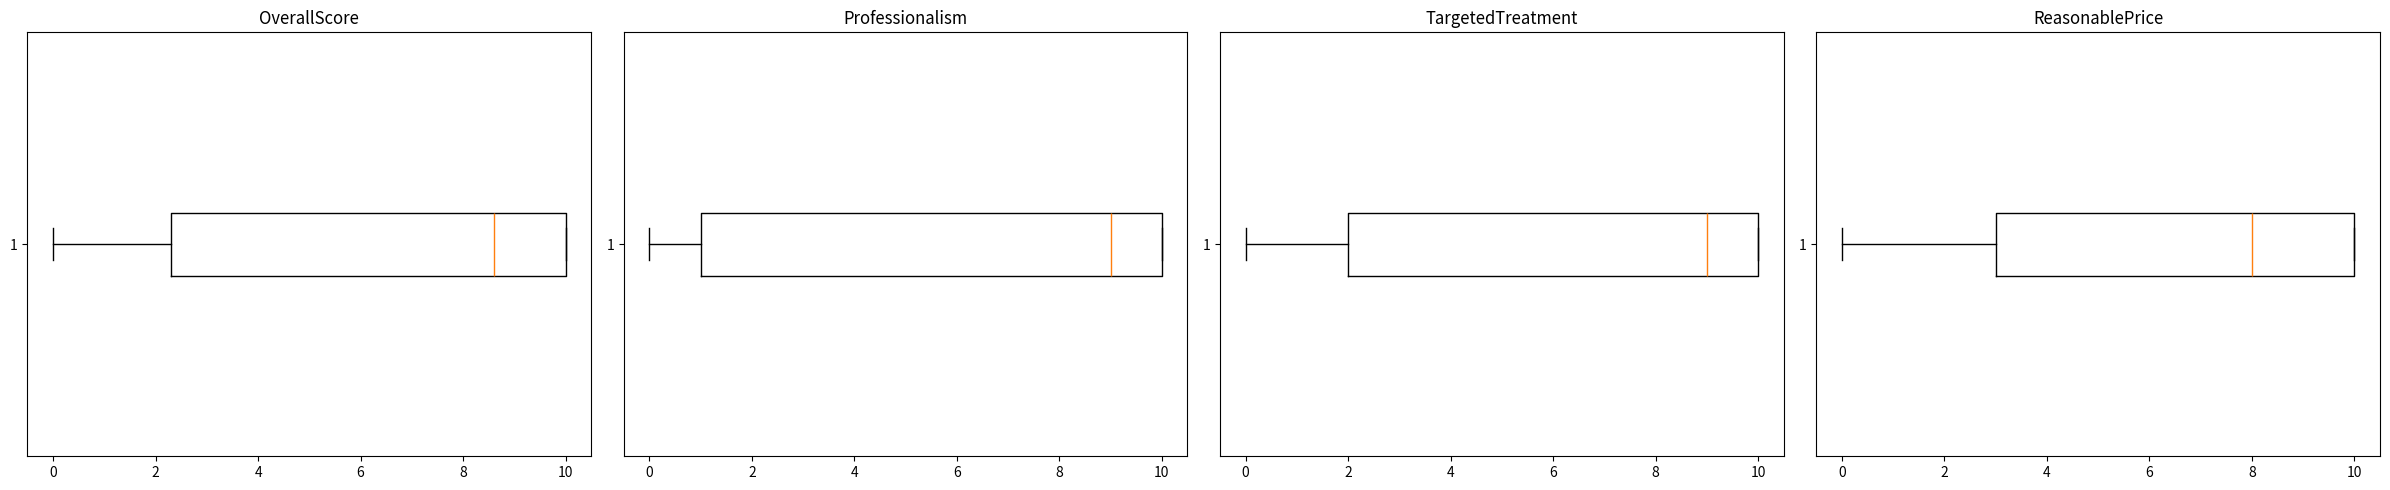

,OverallScore,Professionalism,TargetedTreatment,ReasonablePrice
count,12521.000000,12521.000000,12521.000000,12521.000000
mean,6.579347,6.493651,6.596119,6.693315
std,3.708846,3.948649,3.869668,3.709826
min,0.000000,0.000000,0.000000,0.000000
25%,2.300000,1.000000,2.000000,3.000000
50%,8.600000,9.000000,9.000000,8.000000
75%,10.000000,10.000000,10.000000,10.000000
max,10.000000,10.000000,10.000000,10.000000
range,10.000000,10.000000,10.000000,10.000000


In [9]:
# Visualize the numeric features using box plots
def visualize_numeric_features(df: pd.DataFrame, cols: list[str], width_per_plot: int, height_per_plot: int) -> None:

  # Check if cols exist in the dataframe
  missing_cols = [col for col in cols if col not in df.columns]
  if missing_cols:
      raise ValueError(f"The following columns are not in the DataFrame: {missing_cols}")

  # Get the number of cols and set the fig_size of the subplot
  num_cols = len(cols)
  f, axes = plt.subplots(1, num_cols, figsize=(width_per_plot * num_cols, height_per_plot))

  # Draw the box plot of each numeric feature
  for i, col in enumerate(cols):
      axes[i].boxplot(df[col], vert = False)
      axes[i].set_title(col)
  plt.tight_layout()
  plt.show()

# Get the distribution of the numeric features
def get_numeric_feature_distribution(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:

  # Check if cols exist in the dataframe
  missing_cols = [col for col in cols if col not in df.columns]
  if missing_cols:
      raise ValueError(f"The following columns are not in the DataFrame: {missing_cols}")

  # Get the numeric feature disbtriubtion
  numeric_data_distribution = df[cols].describe()
  numeric_data_distribution.loc["range"] = df[cols].max() - df[cols].min()
  return numeric_data_distribution

visualize_numeric_features(data, ["OverallScore", "Professionalism", "TargetedTreatment", "ReasonablePrice"], 6, 5)
get_numeric_feature_distribution(data, ["OverallScore", "Professionalism", "TargetedTreatment", "ReasonablePrice"])

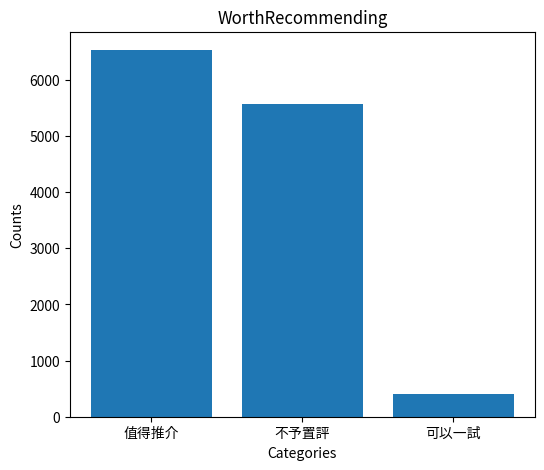

In [10]:
# Visualize the categorical feature using bar plot
def visualize_categorical_features(feature: pd.Series, fig_size: tuple) -> None:

  # Count the occurences of each value
  values = feature.value_counts()
  name = feature.name

  # Draw the bar chart
  plt.figure(figsize = fig_size)
  plt.title(name)
  plt.xlabel("Categories")
  plt.ylabel("Counts")
  plt.bar(values.index, values.values)
  plt.show()

# Draw the bar chart for "WorthREcommending"
visualize_categorical_features(data["WorthRecommending"], (6, 5))

#### 1.5 Normalizing and standardizing the numerical values
In the previous section, we observed that all the numerical features exhibit left-skewness. To address this skewness, we will apply robust scaling to the numerical data in the dataset.a

In [11]:
def numeric_feature_normalization(df: pd.DataFrame, cols: list[str], scaler: sklearn.preprocessing) -> None:
  missing_cols = [col for col in cols if col not in df.columns]
  if missing_cols:
      raise ValueError(f"The following columns are not in the DataFrame: {missing_cols}")

  df[cols] = scaler.fit_transform(df[cols])

# Perform numeric data scaling using RobustScaler
numeric_feature_normalization(data, ["OverallScore", "Professionalism", "TargetedTreatment", "ReasonablePrice"], RobustScaler())

# The numeric data distribution after the scaling
get_numeric_feature_distribution(data, ["OverallScore", "Professionalism", "TargetedTreatment", "ReasonablePrice"])

,OverallScore,Professionalism,TargetedTreatment,ReasonablePrice
count,12521.000000,12521.000000,12521.000000,12521.000000
mean,-0.262423,-0.278483,-0.300485,-0.186669
std,0.481668,0.438739,0.483708,0.529975
min,-1.116883,-1.000000,-1.125000,-1.142857
25%,-0.818182,-0.888889,-0.875000,-0.714286
50%,0.000000,0.000000,0.000000,0.000000
75%,0.181818,0.111111,0.125000,0.285714
max,0.181818,0.111111,0.125000,0.285714
range,1.298701,1.111111,1.250000,1.428571


#### 1.6 Perform ordinal encoding on the categoircal data
One-hot encoding will be performed on categorical feature "WorthRecommending".

In [12]:
def onehot_encoding(df: pd.DataFrame, feature: str, encoder: OneHotEncoder) -> pd.DataFrame:
    df = df.copy()

    onehot_encoded = encoder.fit_transform(df[[feature]])
    onehot_encoded_df = pd.DataFrame(onehot_encoded, columns=encoder.get_feature_names_out([feature]))

    df = pd.concat([df.reset_index(drop=True), onehot_encoded_df.reset_index(drop=True)], axis=1)

    return df.drop(columns=[feature])

# Example usage
data = onehot_encoding(data, "WorthRecommending", OneHotEncoder(sparse_output=False))
# Get the result of one-hot encoding
data.head(5)

,DocChineseName,DocEnglishName,DocRegisteredSpecialty,OverallScore,Professionalism,TargetedTreatment,ReasonablePrice,GeneralComment,WorthRecommending_不予置評,WorthRecommending_值得推介,WorthRecommending_可以一試
0,區志立醫生,Dr AU CHI LAP,家庭醫學,-0.597403,-0.888889,-1.000,0.285714,態度有失、醫德有損 醫護之語調態度令人無所適從 可能人夾人緣自己衡量 醫生態度極差！！自以為...,1.0,0.0,0.0
1,區志立醫生,Dr AU CHI LAP,家庭醫學,-0.948052,-0.777778,-1.000,-1.000000,診效不顯、收費不稱 醫護之語調態度令人無所適從 本人絕對不會再作光顧 媽媽一進入診症室已表明...,1.0,0.0,0.0
2,區志立醫生,Dr AU CHI LAP,家庭醫學,-0.987013,-0.888889,-1.000,-1.000000,態度有失、醫德有損 診証時間極其急趕，快來快去 本人絕對不會再作光顧 收費不合理 明明只復位...,1.0,0.0,0.0
3,區志立醫生,Dr AU CHI LAP,家庭醫學,0.181818,0.111111,0.125,0.285714,仁心仁術、醫德高尚 醫生會主動探索其病因及治療 值得向有需要人仕推介 除問診外，醫生主動解釋...,0.0,1.0,0.0
4,區志立醫生,Dr AU CHI LAP,家庭醫學,-0.818182,-0.666667,-0.750,-1.000000,診效不顯、收費不稱 需要自己主動提出較多的諮詢 可能人夾人緣自己衡量 本人因為肩頸痛痛了多時...,1.0,0.0,0.0


#### 1.7 Visualize Correlation Between Numeric and Categorical Features Using Heatmap

- The result indicates that there is a strong correlation among all numeric targets. This suggests that training a model that accurately predict one numeric target may allow us to utilize similar model architecture to effectively predict other targets as well.
- While for categorical target, such strong relationship is not observed.

<Axes: >

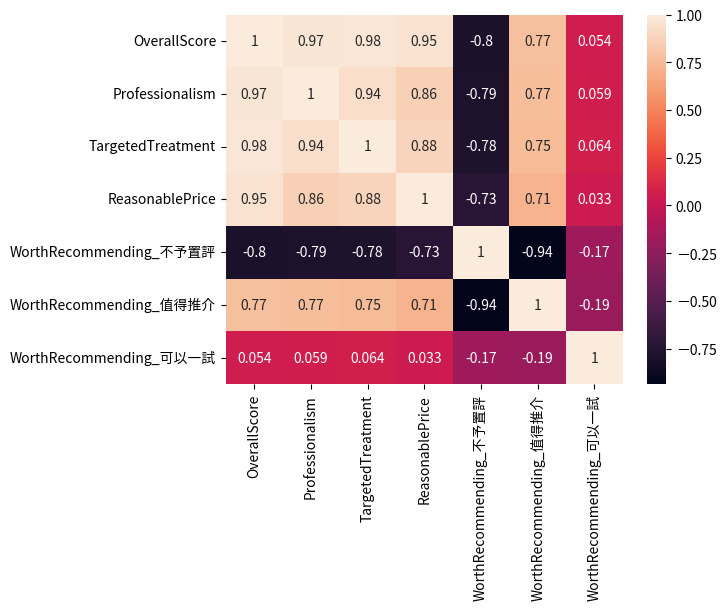

In [13]:
# Visualize the correlation between every two features with a heat map
plt.rcdefaults()
matplotlib.rc('font', family='Taipei Sans TC Beta')
sns.heatmap(data[["OverallScore", "Professionalism", "TargetedTreatment", "ReasonablePrice", "WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]].corr(), annot=True)

In [14]:
# DocChineseName, DocEnglishName, DocRegisteredSpecialty are also dropped as they are irrelvant to our task
data = data.drop(columns = ["DocChineseName", "DocEnglishName", "DocRegisteredSpecialty"])
data.head(5)

,OverallScore,Professionalism,TargetedTreatment,ReasonablePrice,GeneralComment,WorthRecommending_不予置評,WorthRecommending_值得推介,WorthRecommending_可以一試
0,-0.597403,-0.888889,-1.000,0.285714,態度有失、醫德有損 醫護之語調態度令人無所適從 可能人夾人緣自己衡量 醫生態度極差！！自以為...,1.0,0.0,0.0
1,-0.948052,-0.777778,-1.000,-1.000000,診效不顯、收費不稱 醫護之語調態度令人無所適從 本人絕對不會再作光顧 媽媽一進入診症室已表明...,1.0,0.0,0.0
2,-0.987013,-0.888889,-1.000,-1.000000,態度有失、醫德有損 診証時間極其急趕，快來快去 本人絕對不會再作光顧 收費不合理 明明只復位...,1.0,0.0,0.0
3,0.181818,0.111111,0.125,0.285714,仁心仁術、醫德高尚 醫生會主動探索其病因及治療 值得向有需要人仕推介 除問診外，醫生主動解釋...,0.0,1.0,0.0
4,-0.818182,-0.666667,-0.750,-1.000000,診效不顯、收費不稱 需要自己主動提出較多的諮詢 可能人夾人緣自己衡量 本人因為肩頸痛痛了多時...,1.0,0.0,0.0


### Part 2 - Model Training with Pretrained Tokenizer and Embedder

In this section, we will train regression and classification models to predict **"OverallScore,"** **"Professionalism,"** **"TargetedTreatment,"** **"ReasonablePrice,"** and **"WorthRecommending"** based on the **"GeneralComment."**

- We will use **'bert-base-multilingual-cased'** to convert "General Comment" into embedding vectors:
  - This multilingual model supports 104 languages, including English and Chinese.
  - Each words is transformed into a 768-D vectors.
  - Padding and truncation will be perfromed to ensure consistency in the output sequence length
  
- We will train LSTM, Bidirectional LSTM, and GRU models and compare their overall performance.

#### 2.1 Prepare the training and test data

In [15]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(data["GeneralComment"],
                            data[["OverallScore", "Professionalism", "TargetedTreatment", "ReasonablePrice", "WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
                            test_size = 0.2,
                            shuffle = True)

#### 2.2 Convert doctor reviews into embedding vectors
To lower the memory overhead caused by the huge word embedding matrices, we will:
- Set the max encoding length to **128**
- Reduce embedding vector float precision from **float32** to **float16**


In [16]:
# Initialize tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
berd_model = BertModel.from_pretrained("bert-base-multilingual-cased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
berd_model.to(device)

# The function for encoding the comments into embedding vectors using pretrained models
def encode_with_pretrained(data: pd.Series, model: BertModel, tokenizer: BertTokenizer, batch_size: int = 32) -> np.ndarray:
  data_list = data.to_list() # Covert the pd.Series into list
  embeddings_list = []

  # Create batches of data
  data_batch = [data_list[i * batch_size: (i + 1) * batch_size] for i in range((len(data_list) + batch_size - 1) // batch_size)]

  with tqdm(total= len(data_batch), desc="Word embedding") as pbar:
      for i in range(int(len(data_batch))):

        # Tokenize the word using pretrained tokenizer
        word_encoding = tokenizer.batch_encode_plus(
                  data_batch[i],
                  padding= "max_length",
                  truncation=True,
                  max_length= 128,
                  return_tensors="pt"
              )


        # Convert the tokens into word embeddings using pre-trained BERT model.
        with torch.no_grad():
            outputs = model(
                word_encoding["input_ids"].to(device),
                attention_mask=word_encoding["attention_mask"].to(device)
            )
            embeddings = outputs.last_hidden_state.cpu().detach().numpy()
            embeddings_list.append(embeddings)

        # Clear memory
        del word_encoding, outputs, embeddings
        if device == "cuda":
            torch.cuda.empty_cache()
        pbar.update(1)

  # Stack and return the embedded word vectors
  result = np.vstack(embeddings_list)
  del embeddings_list
  gc.collect()

  return result

# Convert the user reviews into word embedding vector using pretrained BERT
# Lower the floating point precision from float 32 to float 16 to lower the size of the numpy array
X_train_embedding = encode_with_pretrained(X_train, berd_model, tokenizer, 32).astype(np.float16)
X_test_embedding = encode_with_pretrained(X_test, berd_model, tokenizer, 32).astype(np.float16)

del berd_model, tokenizer
gc.collect()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Word embedding: 100%|██████████| 79/79 [00:09<00:00,  8.05it/s]


0

#### 2.3 Define the LSTM, GRU, and biderctional LSTM classifier and regressor

In [17]:
# LSTM classifier with BERT embedding as input
# class LSTMClassifier(tf.keras.Model):
#   def __init__(self, num_class : int = 3, unit_num: int = 16):
#
#     # Define the LSTM layers
#     self.model = tf.keras.Sequential()
#     self.model.add(Input((128, 768)))
#     self.model.add(LSTM(unit_num, activation = "tanh", recurrent_activation = "sigmoid", return_sequences = True))
#     self.model.add(Dropout(0.2))
#     self.model.add(LSTM(unit_num, activation = "tanh", recurrent_activation = "sigmoid"))
#     self.model.add(Dropout(0.2))

#     # Dense layers for classification
#     self.model.add(Dense(32, activation = "relu"))
#     self.model.add(Dropout(0.2))
#     self.model.add(Dense(16, activation = "relu"))

#     self.model.add(Dense(num_class, activation = "softmax"))

#   def call(self, x):
#     x = self.model(x)
#     return (x)

# LSTM regressor with BERT embedding as input
class LSTMRegressor(tf.keras.Model):
  def __init__(self, unit_num: int = 16):


    # Define the LSTM layers
    self.model = tf.keras.Sequential()
    self.model.add(Input((128, 768)))
    self.model.add(LSTM(unit_num, activation = "tanh", recurrent_activation = "sigmoid", return_sequences = True))
    self.model.add(Dropout(0.2))
    self.model.add(LSTM(unit_num, activation = "tanh", recurrent_activation = "sigmoid"))
    self.model.add(Dropout(0.2))

    # Dense layers for regression
    self.model.add(Dense(32, activation = "relu"))
    self.model.add(Dropout(0.2))
    self.model.add(Dense(16, activation = "relu"))
    self.model.add(Dropout(0.2))
    self.model.add(Dense(1))

  def call(self, x):
    x = self.model(x)
    return (x)

# GRU classifier with BERT embedding as input
# class GRUClassifier(tf.keras.Model):
#   def __init__(self, num_class : int = 3, unit_num: int = 16):
#

#     # Define the LSTM layers
#     self.model = tf.keras.Sequential()
#     self.model.add(Input((128, 768)))
#     self.model.add(GRU(unit_num, activation = "tanh", recurrent_activation = "sigmoid", return_sequences = True))
#     self.model.add(Dropout(0.2))
#     self.model.add(GRU(unit_num, activation = "tanh", recurrent_activation = "sigmoid"))
#     self.model.add(Dropout(0.2))

#     # Dense layers for classification
#     self.model.add(Dense(32, activation = "relu"))
#     self.model.add(Dropout(0.2))
#     self.model.add(Dense(16, activation = "relu"))

#     self.model.add(Dense(num_class, activation = "softmax"))

#   def call(self, x):
#     x = self.model(x)
#     return (x)

# GRU regressor with BERT embedding as input
class GRURegressor(tf.keras.Model):
  def __init__(self, unit_num: int = 16):

    # Define the GRU layers
    self.model = tf.keras.Sequential()
    self.model.add(Input((128, 768)))
    self.model.add(GRU(unit_num, activation = "tanh", recurrent_activation = "sigmoid", return_sequences = True))
    self.model.add(Dropout(0.2))
    self.model.add(GRU(unit_num, activation = "tanh", recurrent_activation = "sigmoid"))
    self.model.add(Dropout(0.2))

    # Dense layers for regression
    self.model.add(Dense(32, activation = "relu"))
    self.model.add(Dropout(0.2))
    self.model.add(Dense(16, activation = "relu"))
    self.model.add(Dropout(0.2))
    self.model.add(Dense(1))

  def call(self, x):
    x = self.model(x)
    return (x)

# Bidirectional LSTM classifier with BERT embedding as input
# class BidirectionalLstmClassifier(tf.keras.Model):
#   def __init__(self, num_class : int = 3, unit_num: int = 16):
#
#     # Define the Bidirectional LSTM layers
#     self.model = tf.keras.Sequential()
#     self.model.add(Input((128, 768)))
#     self.model.add(Bidirectional(LSTM(unit_num, activation = "tanh", recurrent_activation = "sigmoid", return_sequences = False)))
#     self.model.add(Dropout(0.2))

#     # Dense layers for classification
#     self.model.add(Dense(32, activation = "relu"))
#     self.model.add(Dropout(0.2))
#     self.model.add(Dense(16, activation = "relu"))

#     self.model.add(Dense(num_class, activation = "softmax"))

#   def call(self, x):
#     x = self.model(x)
#     return (x)

# Bidirectional LSTM regressor with BERT embedding as input
class BidirectionalLstmRegressor(tf.keras.Model):
  def __init__(self, unit_num: int = 16):

    # Define the Bidirectional LSTM layers
    self.model = tf.keras.Sequential()
    self.model.add(Input((128, 768)))
    self.model.add(Bidirectional(LSTM(unit_num, activation = "tanh", recurrent_activation = "sigmoid", return_sequences = False)))
    self.model.add(Dropout(0.2))

    # Dense layers for regression
    self.model.add(Dense(32, activation = "relu"))
    self.model.add(Dropout(0.2))
    self.model.add(Dense(16, activation = "relu"))
    self.model.add(Dropout(0.2))
    self.model.add(Dense(1))


  def call(self, x):
    x = self.model(x)
    return (x)

In [18]:
# LSTMClassifier().model.summary()
LSTMRegressor().model.summary()
# GRUClassifier().model.summary()
GRURegressor().model.summary()
# BidirectionalLstmClassifier().model.summary()
BidirectionalLstmRegressor().model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 16)        │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,441 (208.75 KB)

 Trainable params: 53,441 (208.75 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 32)             │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,081 (398.75 KB)

 Trainable params: 102,081 (398.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.4 Define training and model evaluation funciton
- **compute_onehot_class_weight**: Returns class weight for onehot-encoded classification target
- **classification_model_training**: Trains the classifcation model, returns the training time, loss, accuracy, f1 score and model
- **classification_model_evaluation**: Evaluates the trained classification model on the test set, returns the testing accuracy, testing F1 score, AUC, and ROC
- **regression_model_training**: Trains the regression model, returns the training time, loss, $R^2$ score and model
- **regression_model_evaluation**: Evaluates the trained regression model on the test set, returns the testing mean squared error (MSE) and testing $R^2$ score

In [19]:
# Compute class weight for one-hot-encoded classification target
def compute_onehot_class_weight(target: pd.DataFrame) -> dict:
  # Result in an column vector like [0, 1, 2], where each value refers to one class
  indices = np.argmax(target.values, axis = 1)

  #Compute the class weight
  class_weights = sklearn.utils.class_weight.compute_class_weight(
      class_weight = "balanced",
      classes = np.unique(indices),
      y = indices,
  )

  # Convert the class weight into dictionary
  return dict(enumerate(class_weights))

def create_model_instance(model_class: tf.keras.Model, **model_params):
  return model_class(**model_params)

def classification_model_training(X: np.ndarray, y: pd.DataFrame, model_class: tf.keras.Model, model_params: dict, epochs: int = 10) -> tuple:
  # Define the classification model and compute the class weight
  classifier = create_model_instance(model_class, **model_params)
  data_class_weight = compute_onehot_class_weight(y)

  # Compile the model
  classifier.model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss= tf.keras.losses.CategoricalCrossentropy(reduction="sum_over_batch_size"),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.F1Score(average=None, threshold=None, name='f1_score', dtype=None)
    ],
  )

  # Fit the model
  train_start_time = time.time()
  hist = classifier.model.fit(
    x = X,
    y = y,
    batch_size = 32,
    epochs = epochs,
    verbose = 0,
    shuffle = True,
    class_weight = data_class_weight,
  )
  total_train_time = time.time() - train_start_time

  return [classifier, hist, total_train_time]

def classification_model_evaluation(X_test: np.ndarray, y_test: pd.DataFrame, classifier: tf.keras.Model) -> tuple:
  y_pred = classifier.model.predict(X_test,verbose=0)

  y_pred = np.argmax(y_pred, axis = 1)
  y_true = np.argmax(np.array(y_test), axis = 1)
  test_accuracy = accuracy_score(y_true, y_pred)
  test_f1 = f1_score(y_true, y_pred, average="macro")
  cm = confusion_matrix(y_true, y_pred)

  return [test_accuracy, test_f1, cm]

def regression_model_training(X: np.ndarray, y: pd.DataFrame, model_class: tf.keras.Model, model_params : dict, epochs: int = 10) -> tuple:
  # Create the regression model
  regressor = create_model_instance(model_class, **model_params)

  # Copile the model
  regressor.model.compile(
      optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
      loss = tf.keras.losses.MeanSquaredError(reduction = "sum_over_batch_size"),
      metrics = [
          tf.keras.metrics.R2Score(name = "r2")
      ]
  )

  # Fit the model
  train_start_time = time.time()
  hist = regressor.model.fit(
      x = X,
      y = y,
      batch_size = 32,
      epochs = epochs,
      verbose = 0,
      shuffle = True,
  )
  total_train_time = time.time() - train_start_time

  return [regressor, hist, total_train_time]

def regression_model_evaluation(X_test: np.ndarray, y_test: pd.DataFrame, regressor: tf.keras.Model) -> tuple:
  y_pred = regressor.model.predict(X_test,verbose=0)
  y_true = np.array(y_test)
  test_mse = mean_squared_error(y_true, y_pred)
  test_r2 = r2_score(y_true, y_pred)

  return [test_mse, test_r2]

In [20]:
# Define function to train the different models with different number of LSTM and GRU unit for 3 times, average the result and compare their result
def classification_model_comparison_training(X_train: np.ndarray, y_train: pd.DataFrame, X_test: np.ndarray, y_test: pd.DataFrame, unit_nums: list[int], model_class: tf.keras.Model, model_params: dict, epochs: int = 10):
  # Numpy array for storing the accuracy, f1_score, loss, time
  list_len = len(unit_nums)
  accuracies = np.zeros(shape = (list_len, 3, epochs))
  f1_scores = np.zeros(shape = (list_len, 3, epochs))
  losses = np.zeros(shape = (list_len, 3, epochs))
  train_times = np.zeros(shape = (list_len, 3))

  # Numpy array for storing testing accuracy, f1_score
  test_accuracies = np.zeros(shape = (list_len, 3))
  test_f1_scores = np.zeros(shape = (list_len, 3))
  test_cms = np.zeros(shape = (list_len, 3,  model_params.get("num_class", 3), model_params.get("num_class", 3)))

  with tqdm(total= list_len * 3, desc="Comparision training") as pbar:
    for i, unit_num in enumerate(unit_nums):
      for j in range(3):
        # Perform training of the model
        model_params["unit_num"] = unit_num
        model, hist, train_time = classification_model_training(X_train, y_train, model_class , model_params, epochs)
        accuracies[i][j] = np.array(hist.history["accuracy"])
        f1_scores[i][j] = np.array(tf.reduce_mean(hist.history["f1_score"], axis=1))
        losses[i][j] = np.array(hist.history["loss"])
        train_times[i][j] = train_time

        # Perform evaluation of the model
        test_accuracy, test_f1_score, cm = classification_model_evaluation(X_test, y_test, model)
        test_accuracies[i][j] = test_accuracy
        test_f1_scores[i][j] = test_f1_score
        test_cms[i][j] = cm

        os.makedirs(f'/content/classification/{type(model).__name__}', exist_ok=True)
        model.model.save_weights(f'/content/classification/{type(model).__name__}/unit_num-{unit_num}-{j}.weights.h5')
        del model
        gc.collect()
        pbar.update(1)

  accuracies = np.mean(accuracies, axis = 1)
  f1_scores = np.mean(f1_scores, axis = 1)
  losses = np.mean(losses, axis = 1)
  train_times = np.mean(train_times, axis = 1)
  test_accuracies = np.mean(test_accuracies, axis = 1)
  test_f1_scores = np.mean(test_f1_scores, axis = 1)
  test_cms = np.rint(np.mean(test_cms, axis = 1))

  return [accuracies, f1_scores, losses, train_times, test_accuracies, test_f1_scores, test_cms]

def regression_model_comparison_training(X_train: np.ndarray, y_train: pd.DataFrame, X_test: np.ndarray, y_test: pd.DataFrame, unit_nums: list[int], model_class: tf.keras.Model, model_params: dict, epochs: int = 10):
  # Numpy array for storing the accuracy, f1_score, loss, time
  list_len = len(unit_nums)
  r2_scores = np.zeros(shape = (list_len, 3, epochs))
  losses = np.zeros(shape = (list_len, 3, epochs))
  train_times = np.zeros(shape = (list_len, 3))

  # Numpy array for stroring the test mse, test r2 score
  test_mses = np.zeros(shape = (list_len, 3))
  test_r2s = np.zeros(shape = (list_len, 3))

  with tqdm(total= list_len * 3, desc="Comparision training") as pbar:
    for i, unit_num in enumerate(unit_nums):
      for j in range(3):
        model_params["unit_num"] = unit_num
        model, hist, train_time = regression_model_training(X_train, y_train, model_class, model_params, epochs)
        r2_scores[i][j] = np.array(hist.history["r2"])
        losses[i][j] = np.array(hist.history["loss"])
        train_times[i][j] = train_time

        # Perform evaluation on the model
        test_mse , test_r2 = regression_model_evaluation(X_test, y_test, model)
        test_mses[i][j] = test_mse
        test_r2s[i][j] = test_r2

        os.makedirs(f'/content/regression/{y_train.columns[0]}/{type(model).__name__}', exist_ok=True)
        model.model.save_weights(f'/content/regression/{y_train.columns[0]}/{type(model).__name__}/unit_num-{unit_num}-{j}.weights.h5')
        del model
        gc.collect()
        pbar.update(1)

  r2_scores = np.mean(r2_scores, axis = 1)
  losses = np.mean(losses, axis = 1)
  train_times = np.mean(train_times, axis = 1)
  test_mses = np.mean(test_mses, axis = 1)
  test_r2s = np.mean(test_r2s, axis = 1)

  return [r2_scores, losses, train_times, test_mses, test_r2s]

#### 2.5 Train the models and get their performacne metrics
- For the LSTM, GRU, bidirectional LSTM, we will experiment on the model performance having [1, 8, 16] LSTM/GRU units separately
- For each model configuration, 3 trainings will be performed to get the average performance of each model performance

##### 2.5.1 Training of classifiers for categorical target "WorthRecommending"

In [21]:
# unit_nums_list = [1, 8, 16]
# classifier_parameters = {
#   "num_class" : 3,
# }
# lstm_accuracies, lstm_f1_scores, lstm_losses, lstm_traintime, lstm_test_accuracies, lstm_test_f1_scores, lstm_test_cms= classification_model_comparison_training(X_train_embedding,
#                                   y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   X_test_embedding,
#                                   y_test[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   unit_nums_list,
#                                   LSTMClassifier,
#                                   classifier_parameters,
#                                   epochs = 10)
# gc.collect()

# gru_accuracies, gru_f1_scores, gru_losses, gru_traintime, gru_test_accuracies, gru_test_f1_scores, gru_test_cms = classification_model_comparison_training(X_train_embedding,
#                                   y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   X_test_embedding,
#                                   y_test[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   unit_nums_list,
#                                   GRUClassifier,
#                                   classifier_parameters,
#                                   epochs = 10)
# gc.collect()

# blstm_accuracies, blstm_f1_scores, blstm_losses, blstm_traintime, blstm_test_accuracies, blstm_test_f1_scores, blstm_test_cms= classification_model_comparison_training(X_train_embedding,
#                                   y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   X_test_embedding,
#                                   y_test[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   unit_nums_list,
#                                   BidirectionalLstmClassifier,
#                                   classifier_parameters,
#                                   epochs = 10)
# gc.collect()

##### 2.5.2 Training of regressors for numeric target "OverallScore"

In [22]:
regressor_parameters = {}
unit_nums_list = [1, 8, 16]
lstm_overallscore_r2, lstm_overallscore_loss, lstm_overallscore_traintime, lstm_overallscore_test_mse, lstm_overallscore_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["OverallScore"]],
                                  X_test_embedding,
                                  y_test[["OverallScore"]],
                                  unit_nums_list,
                                  LSTMRegressor,
                                  regressor_parameters,
                                  epochs = 10
)
gc.collect()
gru_overallscore_r2, gru_overallscore_loss, gru_overallscore_traintime, gru_overallscore_test_mse, gru_overallscore_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["OverallScore"]],
                                  X_test_embedding,
                                  y_test[["OverallScore"]],
                                  unit_nums_list,
                                  GRURegressor,
                                  regressor_parameters,
                                  epochs = 10
)
gc.collect()
blstm_overallscore_r2, blstm_overallscore_loss, blstm_overallscore_traintime, blstm_overallscore_test_mse, blstm_overallscore_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["OverallScore"]],
                                  X_test_embedding,
                                  y_test[["OverallScore"]],
                                  unit_nums_list,
                                  BidirectionalLstmRegressor,
                                  regressor_parameters,
                                  epochs = 10,

)
gc.collect()

Comparision training: 100%|██████████| 9/9 [09:44<00:00, 64.91s/it]


7097

##### 2.5.3 Training of regressors for numeric target "Professionalism"

In [23]:
lstm_pro_r2, lstm_pro_loss, lstm_pro_traintime, lstm_pro_test_mse, lstm_pro_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["Professionalism"]],
                                  X_test_embedding,
                                  y_test[["Professionalism"]],
                                  unit_nums_list,
                                  LSTMRegressor,
                                  regressor_parameters,
                                  epochs = 10

)
gc.collect()
gru_pro_r2, gru_pro_loss, gru_pro_traintime, gru_pro_test_mse, gru_pro_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["Professionalism"]],
                                  X_test_embedding,
                                  y_test[["Professionalism"]],
                                  unit_nums_list,
                                  GRURegressor,
                                  regressor_parameters,
                                  epochs = 10

)
gc.collect()
blstm_pro_r2, blstm_pro_loss, blstm_pro_traintime, blstm_pro_test_mse, blstm_pro_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["Professionalism"]],
                                  X_test_embedding,
                                  y_test[["Professionalism"]],
                                  unit_nums_list,
                                  BidirectionalLstmRegressor,
                                  regressor_parameters,
                                  epochs = 10

)
gc.collect()

Comparision training: 100%|██████████| 9/9 [09:46<00:00, 65.15s/it]


0

##### 2.5.4 Training of regressors for numeric target "TargetedTreatment"

In [24]:
lstm_tt_r2, lstm_tt_loss, lstm_tt_traintime, lstm_tt_test_mse, lstm_tt_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["TargetedTreatment"]],
                                  X_test_embedding,
                                  y_test[["TargetedTreatment"]],
                                  unit_nums_list,
                                  LSTMRegressor,
                                  regressor_parameters,
                                  epochs = 10
)
gc.collect()
gru_tt_r2, gru_tt_loss, gru_tt_traintime, gru_tt_test_mse, gru_tt_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["TargetedTreatment"]],
                                  X_test_embedding,
                                  y_test[["TargetedTreatment"]],
                                  unit_nums_list,
                                  GRURegressor,
                                  regressor_parameters,
                                  epochs = 10
)
gc.collect()
blstm_tt_r2, blstm_tt_loss, blstm_tt_traintime, blstm_tt_test_mse, blstm_tt_test_r2 = regression_model_comparison_training(
                                  X_train_embedding,
                                  y_train[["TargetedTreatment"]],
                                  X_test_embedding,
                                  y_test[["TargetedTreatment"]],
                                  unit_nums_list,
                                  BidirectionalLstmRegressor,
                                  regressor_parameters,
                                  epochs = 10
)
gc.collect()

Comparision training: 100%|██████████| 9/9 [09:51<00:00, 65.67s/it]


7094

##### 2.5.5 Training of regressors for numeric target "ReasonablePrice"

In [25]:
lstm_rp_r2, lstm_rp_loss, lstm_rp_traintime, lstm_rp_test_mse, lstm_rp_test_r2 = regression_model_comparison_training(
    X_train_embedding,
    y_train[["ReasonablePrice"]],
    X_test_embedding,
    y_test[["ReasonablePrice"]],
    unit_nums_list,
    LSTMRegressor,
    regressor_parameters,
    epochs= 10
)
gc.collect()
gru_rp_r2, gru_rp_loss, gru_rp_traintime, gru_rp_test_mse, gru_rp_test_r2 = regression_model_comparison_training(
    X_train_embedding,
    y_train[["ReasonablePrice"]],
    X_test_embedding,
    y_test[["ReasonablePrice"]],
    unit_nums_list,
    GRURegressor,
    regressor_parameters,
    epochs = 10
)
gc.collect()
blstm_rp_r2, blstm_rp_loss, blstm_rp_traintime, blstm_rp_test_mse, blstm_rp_test_r2 = regression_model_comparison_training(
    X_train_embedding,
    y_train[["ReasonablePrice"]],
    X_test_embedding,
    y_test[["ReasonablePrice"]],
    unit_nums_list,
    BidirectionalLstmRegressor,
    regressor_parameters,
    epochs = 10
)
gc.collect()

Comparision training: 100%|██████████| 9/9 [09:58<00:00, 66.54s/it]


0

#### 2.6 Visualize the experiment result

In [26]:
def convert_test_result_to_df(data: list[np.ndarray], model_names: list[str] = ["LSTM", "GRU", "Bi-LSTM"], unit_nums: list[int] = [1,8,16]):
    if len(data) != len(model_names):
        raise ValueError("Length of data and model_names are not the same")

    # Create DataFrame with model_names as column names and data as the data in the columns
    data_dict = {
        "Unit Numbers": unit_nums
    }
    for name, values in zip(model_names, data):
        data_dict[name] = values

    return pd.DataFrame(data_dict)

def convert_train_result_to_df(data_list: list[np.ndarray], model_names: list[str] = ["LSTM", "GRU", "Bi-LSTM"], unit_nums: list[int] = [1,8,16], epochs_num : int = 10):
    if len(data_list) != len(model_names) != len(unit_nums):
        raise ValueError("Length of data, model_names, and unit_num are not the same")

    # Create DataFrame with model_names-{unit_name} as column names and data as the data in the columns
    data_dict = {
        "Epochs": np.arange(epochs_num) + 1
    }

    for model_name, data in zip(model_names, data_list):
        for i, unit_num in enumerate(unit_nums):
            data_dict[f"{model_name}-{unit_num}"] = data[i]

    return pd.DataFrame(data_dict)

# Plot the line chart for comparison of result
def draw_comparison_linechart(data_list: list[pd.DataFrame], title: str, subplot_titles: list[str], x_label: str, y_labels: list[str], var_name: str) -> None:
    if len(data_list) != len(subplot_titles) != len(y_labels):
        raise ValueError("data_list, subplot_titles and y_labels should be of the same length")

    figure, axes = plt.subplots(1, len(data_list), sharex=True, figsize=(5 * len(data_list), 5))
    figure.suptitle(title)

    # Add padding between subplots and adjust layout
    plt.subplots_adjust(wspace=0.3)

    # Plot each of the subplots
    for i, data_pd in enumerate(data_list):
        dfl = pd.melt(data_pd, id_vars=[x_label], var_name=var_name, value_name="Value")

        sns.lineplot(data=dfl, x=x_label, y="Value", hue=var_name, ax=axes[i],
                    markers=True, dashes=False, marker="o", markersize=6, markevery=1)

        axes[i].set_title(subplot_titles[i])
        axes[i].set_xlabel(x_label)
        axes[i].set_xticks(data_pd[x_label])
        axes[i].set_ylabel(y_labels[i])

        axes[i].get_legend().remove()

    # Create a single legend outside the plots
    handles, labels = axes[-1].get_legend_handles_labels()
    figure.legend(handles, labels, title=var_name,
                 bbox_to_anchor=(1.05, 0.5), loc='center left')

    # Adjust layout to prevent legend overlap
    plt.tight_layout()

    plt.show()

###### 2.6.1 Experimental result of categorical target "WorthRecommending"

In [27]:
model_names = ["LSTM", "GRU", "Bi-LSTM"]

# # Draw line chart for comparing the training performance of the models
# df_accuracies = convert_train_result_to_df(data_list=[lstm_accuracies, gru_accuracies, blstm_accuracies], model_names= model_names, unit_nums=unit_nums_list, epochs_num = 10)
# df_f1_scores = convert_train_result_to_df(data_list=[lstm_f1_scores, gru_f1_scores, blstm_f1_scores], model_names=model_names, unit_nums=unit_nums_list, epochs_num = 10)
# df_losses = convert_train_result_to_df(data_list=[lstm_losses, gru_losses, blstm_losses], model_names=model_names, unit_nums=unit_nums_list, epochs_num = 10)
# draw_comparison_linechart(data_list=[df_accuracies, df_f1_scores, df_losses], title="Classification Model (WorthRecoemmending) Training Performance", subplot_titles=["Accuracy", "F1 Score", "Loss"], x_label="Epochs", y_labels=["Accuracy", "F1 Score", "Loss"], var_name="Model(unit num)")

# # Draw line chart to compare the testing performace of the model
# df_test_accuracies = convert_test_result_to_df(data=[lstm_test_accuracies, gru_test_accuracies, blstm_test_accuracies], model_names=model_names, unit_nums=unit_nums_list)
# df_test_f1 = convert_test_result_to_df(data=[lstm_test_f1_scores, gru_test_f1_scores, blstm_test_f1_scores], model_names=model_names, unit_nums=unit_nums_list)
# df_traintime = convert_test_result_to_df(data=[lstm_traintime, gru_traintime, blstm_traintime], model_names=model_names, unit_nums=unit_nums_list)
# draw_comparison_linechart([df_test_accuracies, df_test_f1, df_traintime], title="Classification Model (WorthRecommending) Test Result and Train Time",  subplot_titles=["Test Accuracy", "Test F1 Score", "Train Time"], x_label="Unit Numbers", y_labels = ["Accuracy", "F1 Score", "Time(s)"], var_name= "Model")

###### 2.6.2 Experimental result of categorical target "OverallScore"

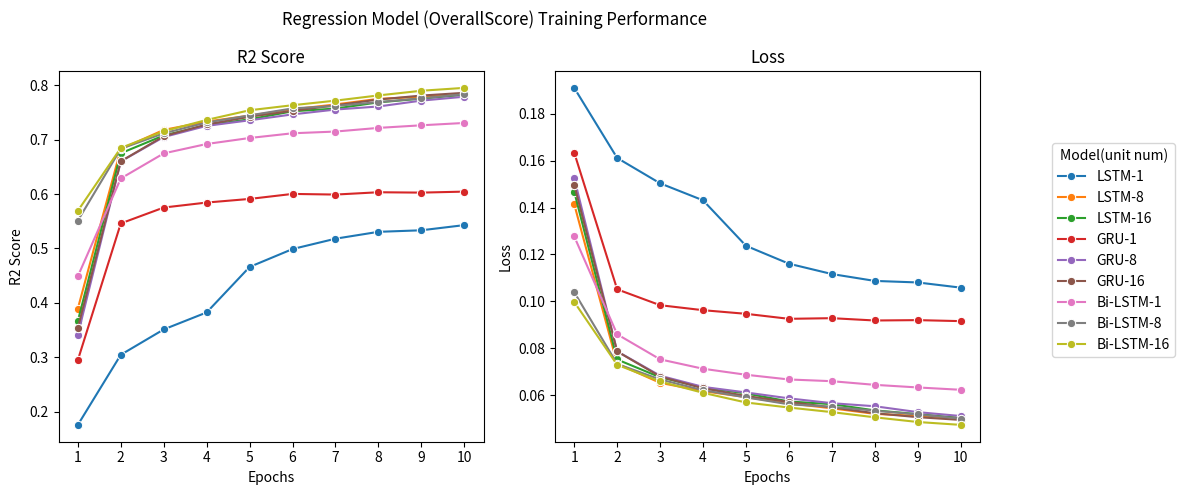

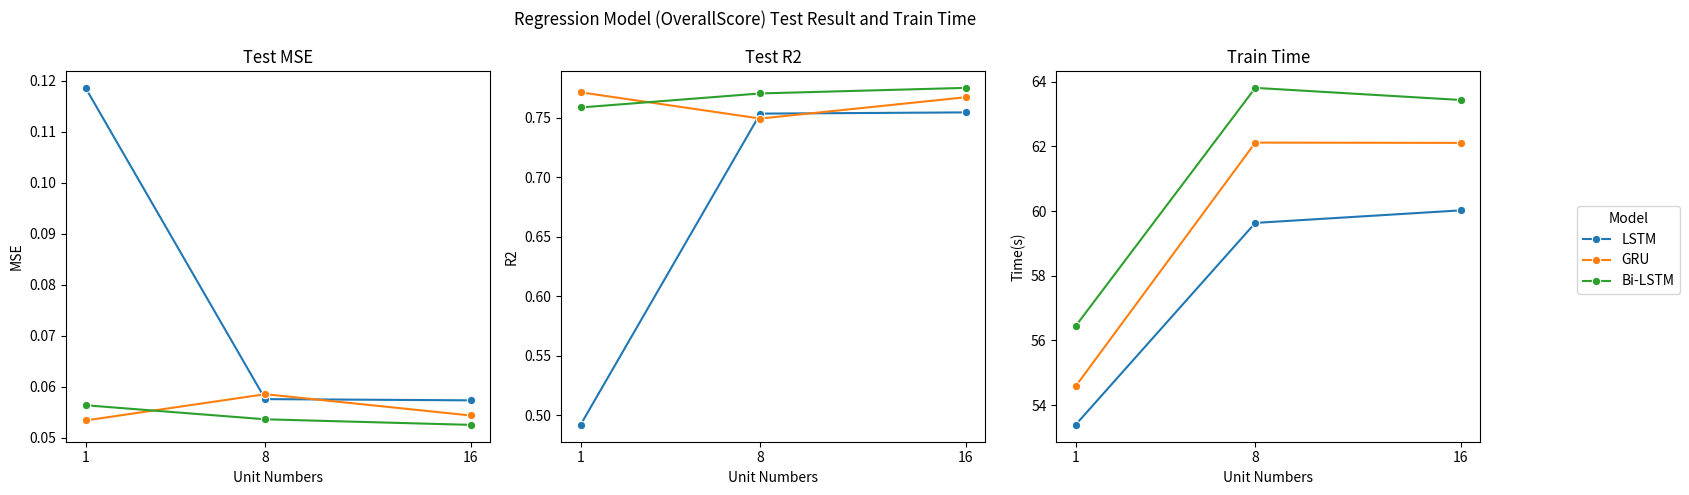

In [28]:
# Draw line chart for comparing the training performance of the models
model_names = ["LSTM", "GRU", "Bi-LSTM"]
df_os_r2 = convert_train_result_to_df(data_list=[lstm_overallscore_r2, gru_overallscore_r2, blstm_overallscore_r2], model_names= model_names, unit_nums=unit_nums_list, epochs_num = 10)
df_os_loss = convert_train_result_to_df(data_list=[lstm_overallscore_loss, gru_overallscore_loss, blstm_overallscore_loss], model_names=model_names, unit_nums=unit_nums_list, epochs_num = 10)
draw_comparison_linechart(data_list=[df_os_r2, df_os_loss], title="Regression Model (OverallScore) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
df_os_mse = convert_test_result_to_df(data=[lstm_overallscore_test_mse, gru_overallscore_test_mse, blstm_overallscore_test_mse], model_names=model_names, unit_nums=unit_nums_list)
df_os_r2 = convert_test_result_to_df(data=[lstm_overallscore_test_r2, gru_overallscore_test_r2, blstm_overallscore_test_r2], model_names=model_names, unit_nums=unit_nums_list)
df_os_traintime = convert_test_result_to_df(data=[lstm_overallscore_traintime, gru_overallscore_traintime, blstm_overallscore_traintime], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart([df_os_mse, df_os_r2, df_os_traintime], title="Regression Model (OverallScore) Test Result and Train Time",  subplot_titles=["Test MSE", "Test R2", "Train Time"], x_label="Unit Numbers", y_labels = ["MSE", "R2", "Time(s)"], var_name= "Model")

###### 2.6.3 Experimental result of categorical target "Professionalism"

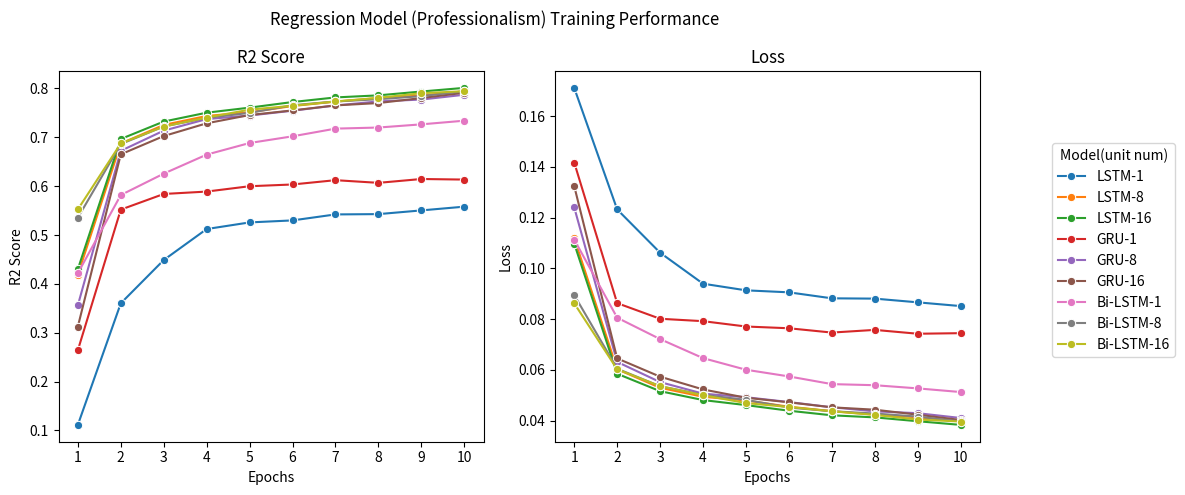

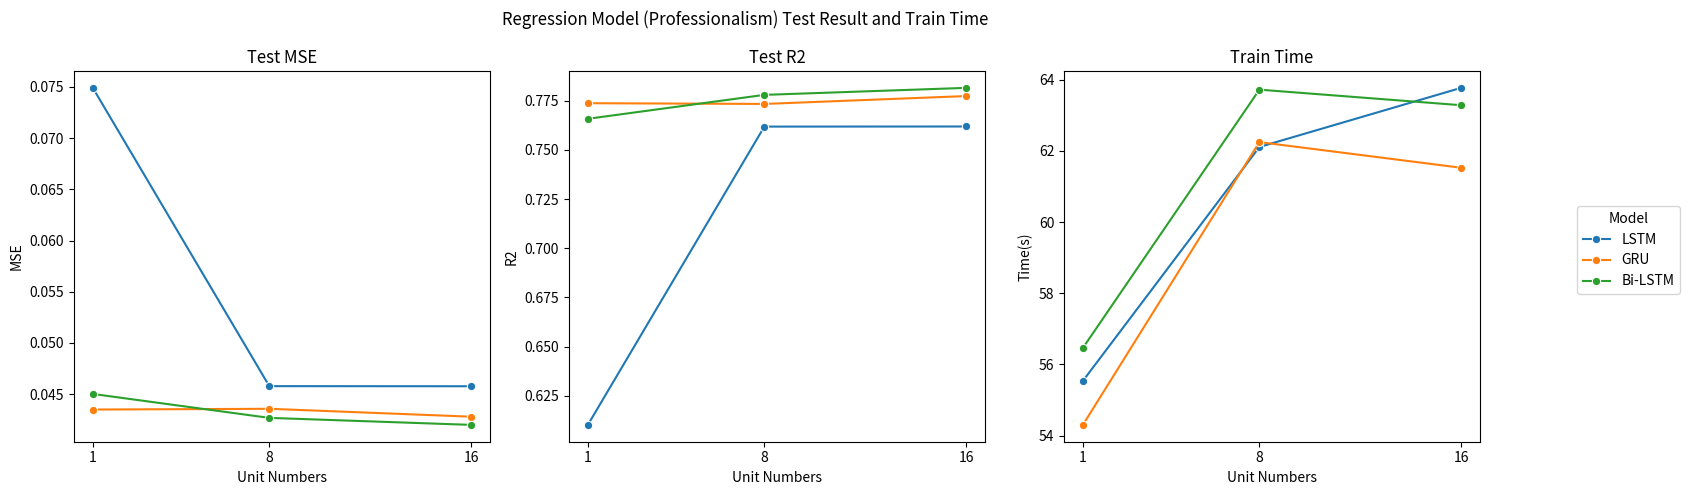

In [29]:
# Draw line chart for comparing the training performance of the models
df_pro_r2 = convert_train_result_to_df(data_list=[lstm_pro_r2, gru_pro_r2, blstm_pro_r2], model_names= model_names, unit_nums=unit_nums_list)
df_pro_loss = convert_train_result_to_df(data_list=[lstm_pro_loss, gru_pro_loss, blstm_pro_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_pro_r2, df_pro_loss], title="Regression Model (Professionalism) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
df_pro_mse = convert_test_result_to_df(data=[lstm_pro_test_mse, gru_pro_test_mse, blstm_pro_test_mse], model_names=model_names, unit_nums=unit_nums_list)
df_pro_r2 = convert_test_result_to_df(data=[lstm_pro_test_r2, gru_pro_test_r2, blstm_pro_test_r2], model_names=model_names, unit_nums=unit_nums_list)
df_pro_traintime = convert_test_result_to_df(data=[lstm_pro_traintime, gru_pro_traintime, blstm_pro_traintime], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart([df_pro_mse, df_pro_r2, df_pro_traintime], title="Regression Model (Professionalism) Test Result and Train Time",  subplot_titles=["Test MSE", "Test R2", "Train Time"], x_label="Unit Numbers", y_labels = ["MSE", "R2", "Time(s)"], var_name= "Model")

###### 2.6.4 Experimental result of numeric target "TargetedTreatment"

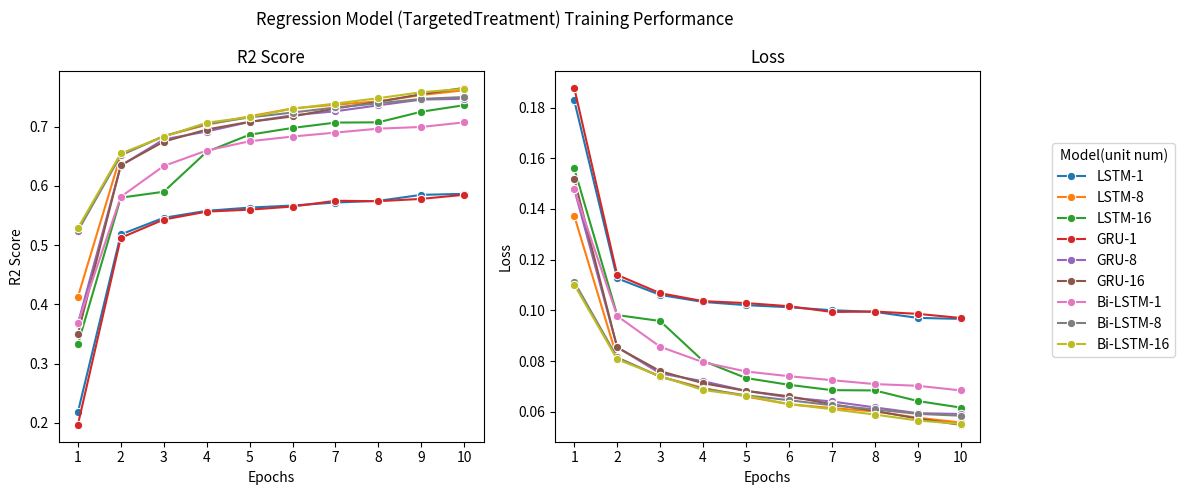

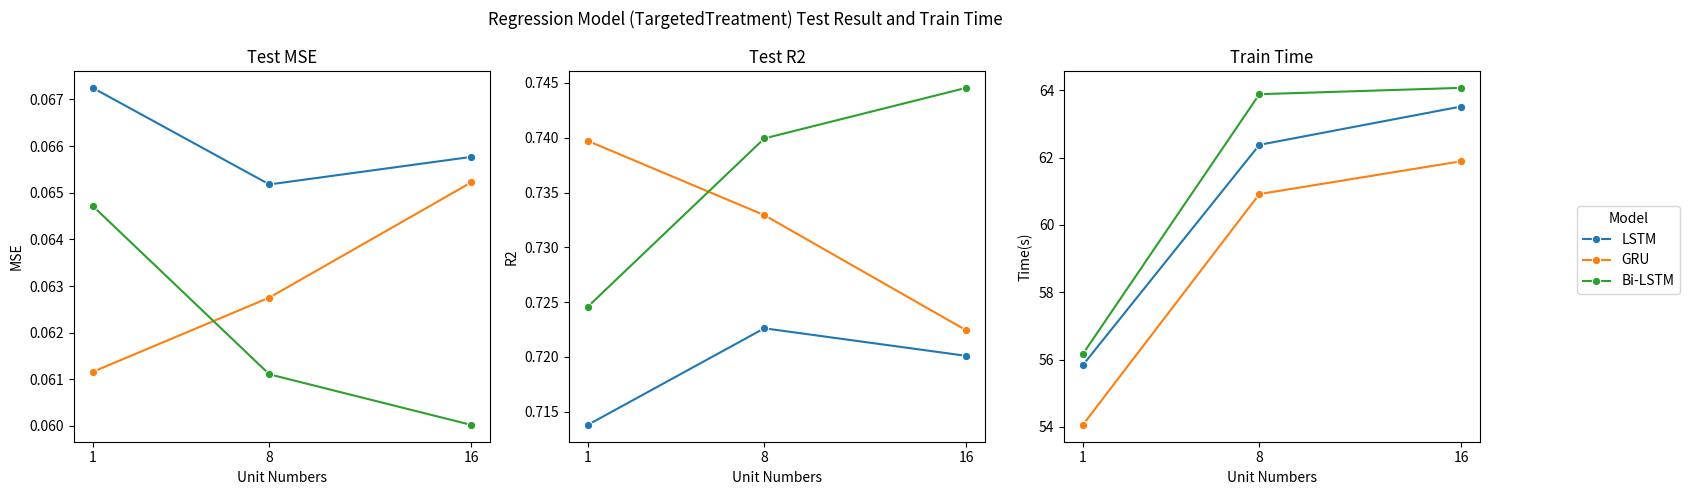

In [30]:
# Draw line chart for comparing the training performance of the models
df_tt_r2 = convert_train_result_to_df(data_list=[lstm_tt_r2, gru_tt_r2, blstm_tt_r2], model_names= model_names, unit_nums=unit_nums_list)
df_tt_loss = convert_train_result_to_df(data_list=[lstm_tt_loss, gru_tt_loss, blstm_tt_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_tt_r2, df_tt_loss], title="Regression Model (TargetedTreatment) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
df_tt_mse = convert_test_result_to_df(data=[lstm_tt_test_mse, gru_tt_test_mse, blstm_tt_test_mse], model_names=model_names, unit_nums=unit_nums_list)
df_tt_r2 = convert_test_result_to_df(data=[lstm_tt_test_r2, gru_tt_test_r2, blstm_tt_test_r2], model_names=model_names, unit_nums=unit_nums_list)
df_tt_traintime = convert_test_result_to_df(data=[lstm_tt_traintime, gru_tt_traintime, blstm_tt_traintime], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart([df_tt_mse, df_tt_r2, df_tt_traintime], title="Regression Model (TargetedTreatment) Test Result and Train Time",  subplot_titles=["Test MSE", "Test R2", "Train Time"], x_label="Unit Numbers", y_labels = ["MSE", "R2", "Time(s)"], var_name= "Model")

###### 2.6.5 Experimental result of numeric target "Reasonable Price"

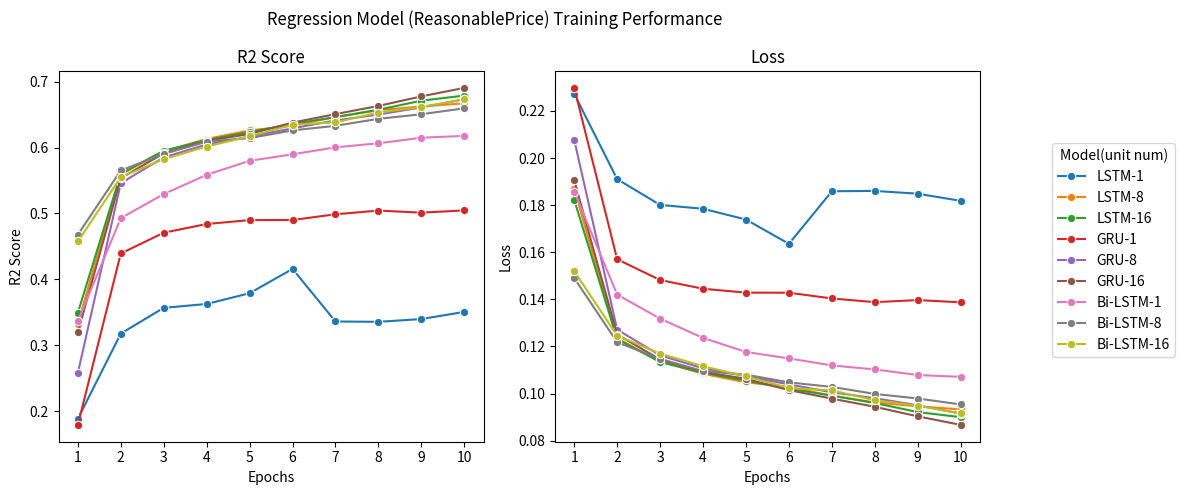

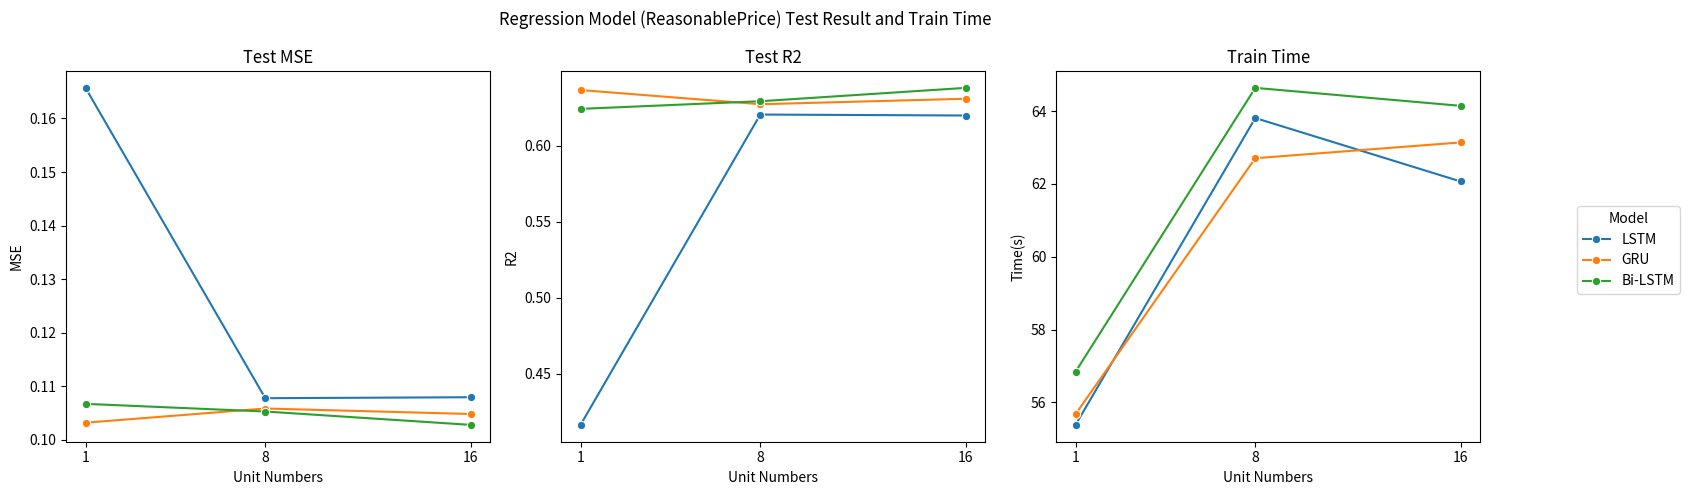

In [31]:
# Draw line chart for comparing the training performance of the models
df_rp_r2 = convert_train_result_to_df(data_list=[lstm_rp_r2, gru_rp_r2, blstm_rp_r2], model_names= model_names, unit_nums=unit_nums_list)
df_rp_loss = convert_train_result_to_df(data_list=[lstm_rp_loss, gru_rp_loss, blstm_rp_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_rp_r2, df_rp_loss], title="Regression Model (ReasonablePrice) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
df_rp_mse = convert_test_result_to_df(data=[lstm_rp_test_mse, gru_rp_test_mse, blstm_rp_test_mse], model_names=model_names, unit_nums=unit_nums_list)
df_rp_r2 = convert_test_result_to_df(data=[lstm_rp_test_r2, gru_rp_test_r2, blstm_rp_test_r2], model_names=model_names, unit_nums=unit_nums_list)
df_rp_traintime = convert_test_result_to_df(data=[lstm_rp_traintime, gru_rp_traintime, blstm_rp_traintime], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart([df_rp_mse, df_rp_r2, df_rp_traintime], title="Regression Model (ReasonablePrice) Test Result and Train Time",  subplot_titles=["Test MSE", "Test R2", "Train Time"], x_label="Unit Numbers", y_labels = ["MSE", "R2", "Time(s)"], var_name= "Model")

### 3. Further Experiment with Bidirectional LSTM without pretrained ebedding

#### 3.1 Tokenization
- We will convert the words in the setence into tokens using off-the-shelf tokenizer "bert-base-multilingual-cased"

In [33]:
# Get the pretrained tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# This function tokenized the words in the comments
def tokenize_word(data: pd.Series, tokenizer: BertTokenizer, batch_size: int = 32) -> np.ndarray:
    data_list = data.to_list()
    token_ids_list = []

    # Create batches of data
    data_batch = [data_list[i * batch_size: (i + 1) * batch_size] for i in range((len(data_list) + batch_size - 1) // batch_size)]

    with tqdm(total=len(data_batch), desc="Word tokenizing") as pbar:
        for i in range(len(data_batch)):
            # Tokenize the word using pretrained tokenizer
            word_encoding = tokenizer.batch_encode_plus(
                data_batch[i],
                padding="max_length",
                truncation=True,
                max_length=128,
                return_tensors="pt"
            )

            # Extract input_ids instead of converting to tokens
            token_ids = word_encoding['input_ids'].numpy()
            token_ids_list.append(token_ids)

            # Clear memory
            del word_encoding
            if device == "cuda":
                torch.cuda.empty_cache()
            pbar.update(1)

    # Concatenate all batches
    result = np.vstack(token_ids_list)
    del token_ids_list
    gc.collect()

    return result

# Convert the user reviews into tokens using pretrained tokenizer
X_train_tokenized = tokenize_word(X_train, tokenizer, 32)
X_test_tokenized = tokenize_word(X_test, tokenizer, 32)

del tokenizer
gc.collect()

Word tokenizing: 100%|██████████| 79/79 [00:02<00:00, 27.55it/s]


0

#### 3.2 Define the regression and classification model with an additional embedding layers

In [34]:
# Define BLSTM-8 classifier witn additional embedding layers
# class BLSTMClassifierWithEmbedding(tf.keras.Model):
#   def __init__(self, num_class : int = 3, unit_num: int = 8, input_dim = 119547):
#     super().__init__()

#     # Define the Bidirectional LSTM layers with an addtional embedding layer
#     self.model = tf.keras.Sequential()
#     self.model.add(Input(shape=(128,)))
#     self.model.add(Embedding(input_dim=input_dim, output_dim=128))
#     self.model.add(Bidirectional(LSTM(unit_num, activation="tanh", recurrent_activation="sigmoid",return_sequences=False)))
#     self.model.add(Dropout(0.2))

#     # Dense layers for classification
#     self.model.add(Dense(32, activation = "relu"))
#     self.model.add(Dropout(0.2))
#     self.model.add(Dense(16, activation = "relu"))

#     self.model.add(Dense(num_class, activation = "softmax"))

#   def call(self, x):
#     x = self.model(x)
#     return (x)

# Define BLSTM-8 regressor with addtional embedding layers
class BLSTMRegressionWithEmbedding(tf.keras.Model):
    def __init__(self, unit_num: int = 8, input_dim = 119547):
      super().__init__()
      # Define the Bidirectional LSTM layers with an addtional embedding layer
      self.model = tf.keras.Sequential()
      self.model.add(Input(shape=(128,)))
      self.model.add(Embedding(input_dim=input_dim, output_dim=128))
      self.model.add(Bidirectional(LSTM(unit_num, activation="tanh", recurrent_activation="sigmoid",return_sequences=False)))
      self.model.add(Dropout(0.2))

      # Dense layers for regression
      self.model.add(Dense(32, activation="relu"))
      self.model.add(Dropout(0.2))
      self.model.add(Dense(16, activation="relu"))
      self.model.add(Dropout(0.2))
      self.model.add(Dense(1))

    def call(self, x):
      x = self.model(x)
      return x

In [35]:
# Get the model summary
BLSTMRegressionWithEmbedding().model.summary()
# BLSTMClassifierWithEmbedding().model.summary()

Model: "sequential_111"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 128)       │    15,302,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_37                │ (None, 16)             │         8,768 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_407 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_333 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_408 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_334 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_409 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_335 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,311,873 (58.41 MB)

 Trainable params: 15,311,873 (58.41 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
unit_nums_list = [8]
classifier_model_params = {
    "num_class" : 3,
    "input_dim" : 119547
}
regressor_model_params = {
    "input_dim" : 119547
}
# blstm_token_wr_accuracies, blstm_token_wr_f1_scores, blstm_token_wr_losses, blstm_token_wr_traintime, blstm_token_wr_test_accuracies, blstm_token_wr_test_f1_scores, blstm_token_wr_test_cms= classification_model_comparison_training(
#                                   X_train_tokenized,
#                                   y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   X_test_tokenized,
#                                   y_test[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   unit_nums_list,
#                                   BLSTMClassifierWithEmbedding,
#                                   classifier_model_params,
#                                   epochs = 10)

blstm_token_os_r2, blstm_token_os_loss, blstm_token_os_traintime, blstm_token_os_test_mse, blstm_token_os_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["OverallScore"]],
                                  X_test_tokenized,
                                  y_test[["OverallScore"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)

blstm_token_pro_r2, blstm_token_pro_loss, blstm_token_pro_traintime, blstm_token_pro_test_mse, blstm_token_pro_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["Professionalism"]],
                                  X_test_tokenized,
                                  y_test[["Professionalism"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)
blstm_token_tt_r2, blstm_token_tt_loss, blstm_token_tt_traintime, blstm_token_tt_test_mse, blstm_token_tt_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["TargetedTreatment"]],
                                  X_test_tokenized,
                                  y_test[["TargetedTreatment"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)
blstm_token_rp_r2, blstm_token_rp_loss, blstm_token_rp_traintime, blstm_token_rp_test_mse, blstm_token_rp_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["ReasonablePrice"]],
                                  X_test_tokenized,
                                  y_test[["ReasonablePrice"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)

Comparision training: 100%|██████████| 3/3 [03:52<00:00, 77.59s/it]


#### 3.4 Visualization of the testing result

In [37]:
# # Draw line chart for the training performance of the models accorss epochs
# model_names = ["BLSTM-with-embedding-layer"]
# unit_nums_list = [8]
# df_token_wr_accuracies = convert_train_result_to_df(data_list=[blstm_token_wr_accuracies], model_names= model_names, unit_nums=unit_nums_list)
# df_token_wr_f1_scores = convert_train_result_to_df(data_list=[blstm_token_wr_f1_scores], model_names=model_names, unit_nums=unit_nums_list)
# draw_comparison_linechart(data_list=[df_token_wr_accuracies, df_token_wr_f1_scores], title="Classification Model with Embeedding Layer (Worth Recommending) Training Performance", subplot_titles=["Accuracy", "F1 score"], x_label="Epochs", y_labels=["accuracies Score", "scores"], var_name="Model(unit num)")

# # Draw line chart to compare the testing performace of the model
# print(f"The testing accuracy is: {blstm_token_wr_test_accuracies}")
# print(f"The testing f1 is: {blstm_token_wr_test_f1_scores}")
# print(f"The average training time of the model is: {blstm_token_wr_traintime}")

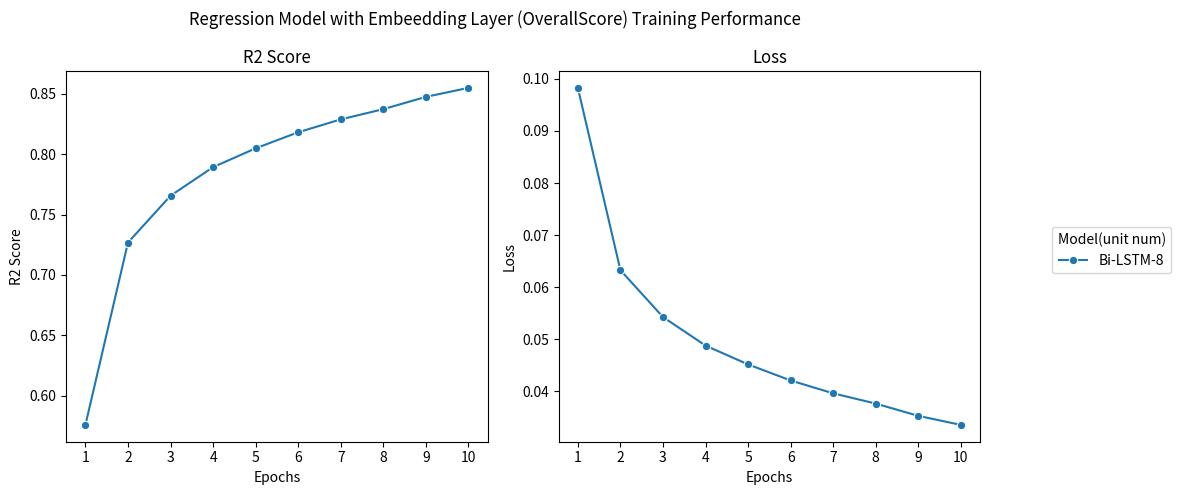

The testing MSE is: [0.05593084]
The testing R^2 is: [0.76039294]
The average training time of the model is: [73.89024854]


In [38]:
# Draw line chart for the training performance of the models accorss epochs
model_names = ["Bi-LSTM"]
df_token_os_r2 = convert_train_result_to_df(data_list=[blstm_token_os_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_os_loss = convert_train_result_to_df(data_list=[blstm_token_os_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_os_r2, df_token_os_loss], title="Regression Model with Embeedding Layer (OverallScore) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_os_test_mse}")
print(f"The testing R^2 is: {blstm_token_os_test_r2}")
print(f"The average training time of the model is: {blstm_token_os_traintime}")

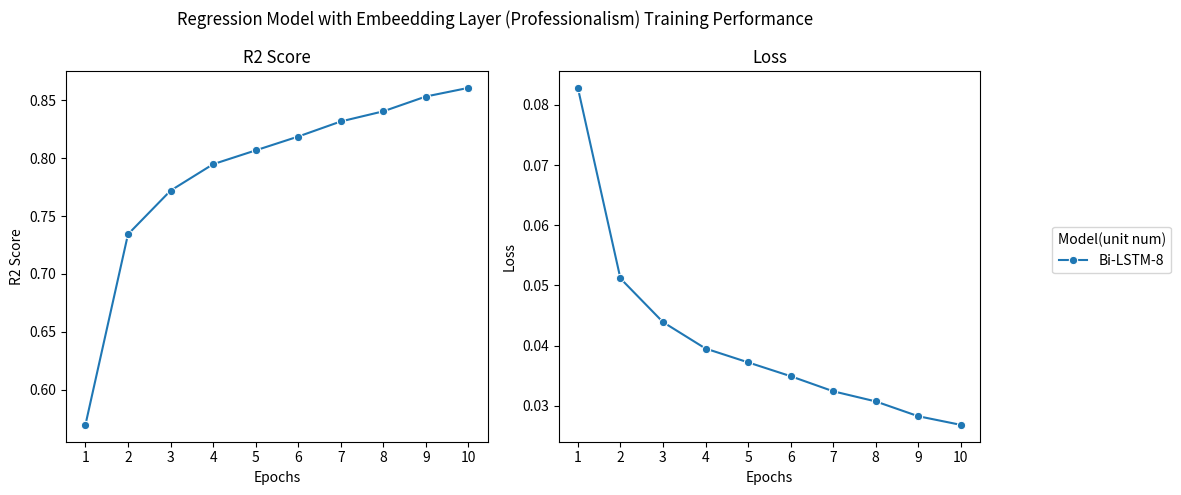

The testing MSE is: [0.04632542]
The testing R^2 is: [0.75898427]
The average training time of the model is: [73.97367287]


In [39]:
# Draw line chart for the training performance of the models accorss epochs
df_token_pro_r2 = convert_train_result_to_df(data_list=[blstm_token_pro_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_pro_loss = convert_train_result_to_df(data_list=[blstm_token_pro_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_pro_r2, df_token_pro_loss], title="Regression Model with Embeedding Layer (Professionalism) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_pro_test_mse}")
print(f"The testing R^2 is: {blstm_token_pro_test_r2}")
print(f"The average training time of the model is: {blstm_token_pro_traintime}")

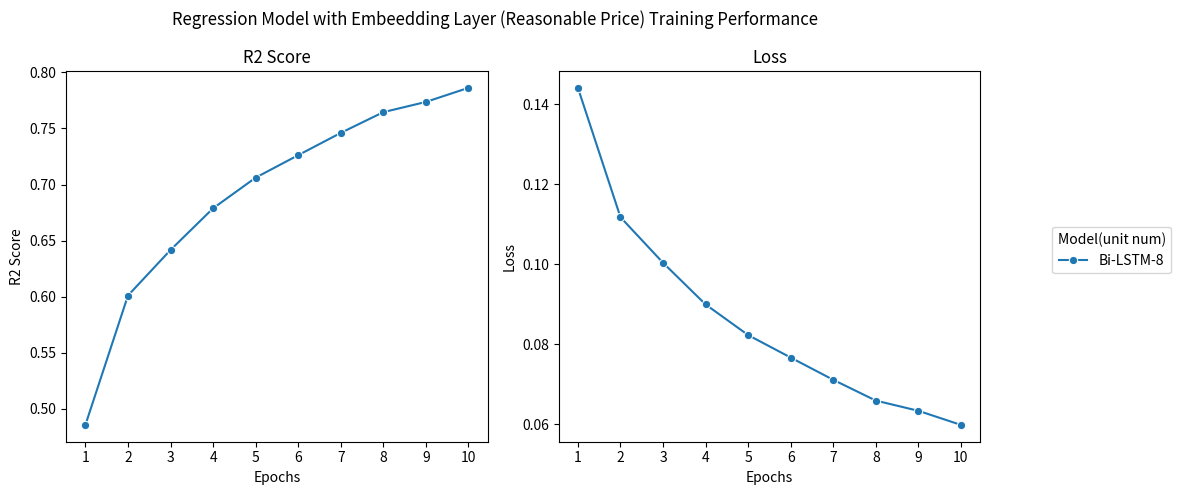

The testing MSE is: [0.11891905]
The testing R^2 is: [0.58114835]
The average training time of the model is: [74.45492736]


In [40]:
# Draw line chart for the training performance of the models accorss epochs
df_token_rp_r2 = convert_train_result_to_df(data_list=[blstm_token_rp_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_rp_loss = convert_train_result_to_df(data_list=[blstm_token_rp_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_rp_r2, df_token_rp_loss], title="Regression Model with Embeedding Layer (Reasonable Price) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_rp_test_mse}")
print(f"The testing R^2 is: {blstm_token_rp_test_r2}")
print(f"The average training time of the model is: {blstm_token_rp_traintime}")

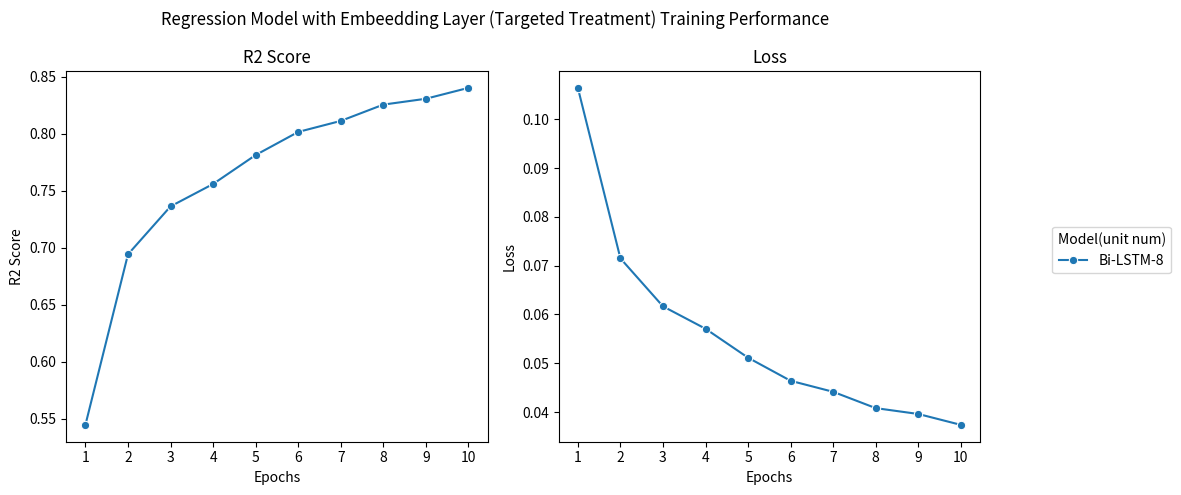

The testing MSE is: [0.06841517]
The testing R^2 is: [0.70883657]
The average training time of the model is: [73.89251749]


In [41]:
# Draw line chart for the training performance of the models accorss epochs
df_token_tt_r2 = convert_train_result_to_df(data_list=[blstm_token_tt_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_tt_loss = convert_train_result_to_df(data_list=[blstm_token_tt_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_tt_r2, df_token_tt_loss], title="Regression Model with Embeedding Layer (Targeted Treatment) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_tt_test_mse}")
print(f"The testing R^2 is: {blstm_token_tt_test_r2}")
print(f"The average training time of the model is: {blstm_token_tt_traintime}")

### Part 4 Hyperparameter Tuning 2


In [42]:
from kerastuner import HyperParameters
### Define the classifier model building function
# def bert_classification_model_building(hp):

#   model = tf.keras.Sequential();
#   model.add(Input(shape=(128,)))


#   """
#   Tune the l2 regularization rate
#   """
#   hp_l2 = hp.Float("l2_regularizer", min_value=1e-4, max_value=1e-2, sampling="log")
#   model.add(Embedding(input_dim=119547, output_dim=128,
#             embeddings_regularizer=tf.keras.regularizers.l2(hp_l2)))

#   """
#   Tune the number of LSTM units in the first
#   bidirectional LSTM layers.
#   The dropout rate will also be tuned.
#   """

#   hp_lstm_units = hp.Choice("lstm_unit", values = [8, 16, 32, 64])
#   hp_dropout = hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)

#   model.add(
#       Bidirectional(
#           LSTM(
#               units = hp_lstm_units,
#               activation="tanh",
#               recurrent_activation="sigmoid",
#               return_sequences=False,
#               kernel_regularizer=tf.keras.regularizers.l2(hp_l2)
#             )
#         )
#     )

#   """
#   Tune the number of units in the feedforward layer
#   Tune the dropout rate in the feedforward layer
#   """

#   # Dense layers with L2 regularization
#   hp_dense_units = hp.Choice("dense_unit", values=[16, 32, 64])

#   model.add(Dense(
#       units=hp_dense_units,
#       activation=None,
#       use_bias=True,  # Changed to True
#       kernel_regularizer=tf.keras.regularizers.l2(hp_l2)
#   ))
#   model.add(BatchNormalization())
#   model.add(Activation("relu"))
#   model.add(Dropout(hp_dropout))

#   model.add(Dense(
#       units=hp_dense_units // 2,
#       activation=None,
#       use_bias=True,  # Changed to True
#       kernel_regularizer=tf.keras.regularizers.l2(hp_l2)
#   ))
#   model.add(BatchNormalization())
#   model.add(Activation("relu"))
#   model.add(Dropout(hp_dropout))


#   model.add(Dense(3, activation='softmax'))

#   """
#   Tune the learning rate, decay steps, and gradient gradient clipping value
#   """
#   hp_learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
#   hp_decay_steps = hp.Int("decay_steps", min_value=1000, max_value=5000, step=1000)
#   hp_clip_value = hp.Float("clip_value", min_value=0.5, max_value=2.0, step=0.5)

#   initial_learning_rate = hp_learning_rate
#   decay_schedule = tf.keras.optimizers.schedules.CosineDecay(
#       initial_learning_rate,
#       decay_steps=hp_decay_steps
#   )

#   optimizer = tf.keras.optimizers.Adam(
#       learning_rate=decay_schedule,
#       clipvalue=hp_clip_value
#   )

#   model.compile(
#       optimizer=optimizer,
#       loss=tf.keras.losses.CategoricalCrossentropy(
#           label_smoothing=0.1
#       ),
#       metrics=[
#           tf.keras.metrics.CategoricalAccuracy(),
#           tf.keras.metrics.F1Score(name="f1_score", average="macro")
#       ],
#   )

#   return model

### Define the regression model building function
def bert_regression_model_building(hp):

  model = tf.keras.Sequential();
  model.add(Input(shape=(128,)))
  model.add(Embedding(input_dim=119547, output_dim=128))

  """
  Tune the number of LSTM units in the first bidirectional LSTM layers.
  The dropout rate will also be tuned.
  """

  hp_lstm_units = hp.Choice("lstm_unit", values = [16, 32])
  hp_dropout = hp.Float("dropout_rate", min_value=0.2, max_value=0.4, step=0.1)
  model.add(
      Bidirectional(
          LSTM(
              units = hp_lstm_units,
              activation="tanh",
              recurrent_activation="sigmoid",
              return_sequences=False
            )
        )
    )

  """
  Tune the number of units in the feedforward layer
  """
  hp_dense_units = hp.Choice("dense_unit", values = [16,32])
  model.add(Dense(
      units = hp_dense_units,
      activation = None,
      use_bias = False,
  ))
  model.add(BatchNormalization())
  model.add(Activation("relu"))
  model.add(Dropout(hp_dropout))
  model.add(Dense(
      units = hp_dense_units // 2,
      activation = None,
      use_bias = False,
  ))
  model.add(BatchNormalization())
  model.add(Activation("relu"))
  model.add(Dropout(hp_dropout))
  model.add(Dense(1))

  """Tune the learning rate, decay steps and gradient clip value of the optimizer"""
  hp_learning_rate = hp.Float("learning_rate", min_value = 1e-4, max_value = 1e-2, sampling="log")
  hp_decay_steps = hp.Int("decay_step", min_value = 1000, max_value = 5000, step = 1000)
  hp_clip_value = hp.Float("clip_value", min_value=0.5, max_value=2.0, step=0.5)
  initial_learing_rate = hp_learning_rate
  decay_schedule = tf.keras.optimizers.schedules.CosineDecay(
      initial_learing_rate,
      decay_steps = hp_decay_steps,
  )

  optimizer = tf.keras.optimizers.Adam(
      learning_rate = decay_schedule,
      clipvalue = hp_clip_value,
  )
  model.compile(
      optimizer = optimizer,
      loss = tf.keras.losses.MeanSquaredError(),
      metrics=[
          tf.keras.metrics.MeanAbsoluteError(name = "mae"),
          tf.keras.metrics.R2Score(name = "r2_score"),
      ],
  )
  return model

# Initialize the HyperParameters object
hp = HyperParameters()

# Build the model
model = bert_regression_model_building(hp)

# Print the model summary
model.summary()

<ipython-input-42-593860b169fc>:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import HyperParameters


Model: "sequential_124"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 128, 128)       │    15,302,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_50                │ (None, 32)             │        18,560 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_372 (Dense)               │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_446 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_373 (Dense)               │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_447 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_374 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,321,321 (58.45 MB)

 Trainable params: 15,321,273 (58.45 MB)

 Non-trainable params: 48 (192.00 B)

In [43]:
# Compute class weight for one-hot-encoded classification target
def compute_onehot_class_weight(target: pd.DataFrame) -> dict:
  # Result in an column vector like [0, 1, 2], where each value refers to one class
  indices = np.argmax(target.values, axis = 1)

  #Compute the class weight
  class_weights = sklearn.utils.class_weight.compute_class_weight(
      class_weight = "balanced",
      classes = np.unique(indices),
      y = indices,
  )

  # Convert the class weight into dictionary
  return dict(enumerate(class_weights))

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)

In [44]:
### Function to search for the best hyperparameter using keras tuner
def model_tuning(
    X: np.ndarray,
    y: pd.DataFrame,
    model_builder: Callable[[kt.HyperParameters], tf.keras.Model],
    tuner_args: dict,
    searching_args: dict,
    classification: bool = True
) -> kt.Tuner:
  tuner = kt.Hyperband(
      hypermodel= model_builder,
      objective = tuner_args.get("objective", "val_loss"),
      max_epochs = tuner_args.get("max_epochs", 10),
      directory = tuner_args.get("directory", "keras_tuner"),
      project_name =tuner_args.get("project_name", "hp_tuning"),
      overwrite = tuner_args.get("overwrite", False),
  )
  if classification:
    data_class_weight = compute_onehot_class_weight(y[
        [
            "WorthRecommending_不予置評",
            "WorthRecommending_值得推介",
            "WorthRecommending_可以一試",
        ]
    ])
    tuner.search(
      X,
      y,
      epochs = tuner_args.get("epochs", 50),
      validation_split = tuner_args.get("validation_split", 0.2),
      callbacks=[stop_early],
      class_weight = data_class_weight,

    )
  else :
    tuner.search(
      X,
      y,
      epochs = tuner_args.get("epochs", 50),
      validation_split = tuner_args.get("validation_split", 0.2),
      callbacks=[stop_early],
    )

  return tuner

In [45]:
# bert_classification_tuner_args = {
#     "objective": kt.Objective("val_f1_score", direction = "max"),
#     "max_epochs": 10,
#     "directory": "bert_keras_tuner",
#     "project_name": "wr_tuning",
#     "overwrite": True,
# }
# bert_wr_searching_args = {
#     "epochs": 10,
#     "validation_split": 0.2,
# }

# bert_wr_tuner = model_tuning(
#     X_train_tokenized,
#     y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#     bert_classification_model_building,
#     bert_classification_tuner_args,
#     bert_wr_searching_args,
#     True,
# )

In [46]:
bert_regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 10,
    "directory": "bert_keras_tuner",
    "project_name": "os_tuning",
    "overwrite": True,
}
bert_regression_searching_args = {
    "epochs": 10,
    "validation_split": 0.2,
}

bert_os_tuner = model_tuning(
    X_train_tokenized,
    y_train[["OverallScore"]],
    bert_regression_model_building,
    bert_regression_tuner_args,
    bert_regression_searching_args,
    False,
)

Trial 30 Complete [00h 01m 27s]
val_r2_score: 0.6133344769477844

Best val_r2_score So Far: 0.7711402177810669
Total elapsed time: 00h 20m 02s


In [47]:
bert_regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 5,
    "directory": "bert_keras_tuner",
    "project_name": "pro_tuning",
    "overwrite": True,
}
bert_regression_searching_args = {
    "epochs": 5,
    "validation_split": 0.2,
}

bert_pro_tuner = model_tuning(
    X_train_tokenized,
    y_train[["Professionalism"]],
    bert_regression_model_building,
    bert_regression_tuner_args,
    bert_regression_searching_args,
    False,
)

Trial 10 Complete [00h 00m 49s]
val_r2_score: 0.6680829524993896

Best val_r2_score So Far: 0.7857123613357544
Total elapsed time: 00h 05m 36s


In [48]:
bert_regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 10,
    "directory": "bert_keras_tuner",
    "project_name": "rp_tuning",
    "overwrite": True,
}
bert_regression_searching_args = {
    "epochs": 10,
    "validation_split": 0.2,
}

bert_rp_tuner = model_tuning(
    X_train_tokenized,
    y_train[["ReasonablePrice"]],
    bert_regression_model_building,
    bert_regression_tuner_args,
    bert_regression_searching_args,
    False,
)

Trial 30 Complete [00h 01m 27s]
val_r2_score: 0.6070024967193604

Best val_r2_score So Far: 0.640516996383667
Total elapsed time: 00h 20m 20s


In [49]:
bert_regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 10,
    "directory": "bert_keras_tuner",
    "project_name": "tt_tuning",
    "overwrite": True,
}
bert_regression_searching_args = {
    "epochs": 10,
    "validation_split": 0.2,
}

bert_tt_tuner = model_tuning(
    X_train_tokenized,
    y_train[["TargetedTreatment"]],
    bert_regression_model_building,
    bert_regression_tuner_args,
    bert_regression_searching_args,
    False,
)

Trial 30 Complete [00h 01m 29s]
val_r2_score: 0.6846697330474854

Best val_r2_score So Far: 0.7334342002868652
Total elapsed time: 00h 20m 20s


In [50]:
### Define a function that find the best epochs to train

def find_best_train_epochs(
    tuner : kt.Tuner,
    X_train: np.ndarray,
    y_train: pd.DataFrame,
    X_test: np.ndarray,
    y_test: pd.DataFrame,
    classification: bool = True):

  ### Train the models for 50 epochs and find the best training epochs
  best_hps = tuner.get_best_hyperparameters()[0]
  epoch_finding_model = tuner.hypermodel.build(best_hps)

  history = epoch_finding_model.fit(X_train, y_train,
                    epochs = 50, validation_split = 0.2)

  best_epoch = -1
  if classification is True:
    val_f1_per_epoch = history.history["val_f1_score"]
    best_epoch = val_f1_per_epoch.index(max(val_f1_per_epoch)) + 1
  else:
    val_r2_per_epoch = history.history['val_r2_score']
    best_epoch = val_r2_per_epoch.index(max(val_r2_per_epoch)) + 1

  ### Train the model with the best number of epoch found
  best_model = tuner.hypermodel.build(best_hps)
  best_model.fit(X_train, y_train, epochs = best_epoch, validation_split = 0.2)

  ### Evaluate the best model
  result = best_model.evaluate(X_test, y_test)

  ### return the model and the result
  return best_model, result

In [51]:
# bert_wr_best_tuned_model, bert_wr_test_result = find_best_train_epochs(
#     tuner = bert_wr_tuner,
#     X_train = X_train_tokenized,
#     y_train = y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#     X_test = X_test_tokenized,
#     y_test = y_test[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#     classification = True
# )

# print(f'Model loss value = {bert_wr_test_result[0]}')
# print(f'Model categorical accuracy = {bert_wr_test_result[1]}')
# print(f'Model R2 score = {bert_wr_test_result[2]}')

In [52]:
bert_os_best_tuned_model, bert_os_test_result = find_best_train_epochs(
    tuner = bert_os_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["OverallScore"]],
    X_test = X_test_tokenized,
    y_test = y_test[["OverallScore"]],
    classification = False
)
print(f'Model loss value = {bert_os_test_result[0]}')
print(f'Model mean absolute error = {bert_os_test_result[1]}')
print(f'Model R2 score = {bert_os_test_result[2]}')

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.2627 - mae: 0.3606 - r2_score: -0.1161 - val_loss: 0.0693 - val_mae: 0.1853 - val_r2_score: 0.7034
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0736 - mae: 0.1984 - r2_score: 0.6824 - val_loss: 0.0632 - val_mae: 0.1874 - val_r2_score: 0.7292
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0683 - mae: 0.1885 - r2_score: 0.7038 - val_loss: 0.0545 - val_mae: 0.1614 - val_r2_score: 0.7667
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0619 - mae: 0.1788 - r2_score: 0.7358 - val_loss: 0.0542 - val_mae: 0.1627 - val_r2_score: 0.7677
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0608 - mae: 0.1782 - r2_score: 0.7356 - val_loss: 0.0543 - val_mae: 0.1634 - val_r2_score: 0.7673
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0633 - mae: 0.1796 - r2_score: 0.7234 - val_loss: 0.0546 - val_mae: 0.1636 - val_r2_score: 0.7661
Epoch 7/50
251/251 ━━━━━━━━━━━━━

In [53]:
bert_pro_best_tuned_model, bert_pro_test_result = find_best_train_epochs(
    tuner = bert_pro_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["Professionalism"]],
    X_test = X_test_tokenized,
    y_test = y_test[["Professionalism"]],
    classification = False
)
print(f'Model loss value = {bert_pro_test_result[0]}')
print(f'Model mean absolute error = {bert_pro_test_result[1]}')
print(f'Model R2 score = {bert_pro_test_result[2]}')

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.2397 - mae: 0.3702 - r2_score: -0.2341 - val_loss: 0.1764 - val_mae: 0.3560 - val_r2_score: 0.0870
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0948 - mae: 0.2324 - r2_score: 0.5018 - val_loss: 0.0579 - val_mae: 0.1789 - val_r2_score: 0.7003
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0775 - mae: 0.2047 - r2_score: 0.6004 - val_loss: 0.0471 - val_mae: 0.1461 - val_r2_score: 0.7563
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0716 - mae: 0.1954 - r2_score: 0.6292 - val_loss: 0.0450 - val_mae: 0.1403 - val_r2_score: 0.7669
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0671 - mae: 0.1888 - r2_score: 0.6528 - val_loss: 0.0442 - val_mae: 0.1395 - val_r2_score: 0.7714
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0674 - mae: 0.1889 - r2_score: 0.6509 - val_loss: 0.0440 - val_mae: 0.1394 - val_r2_score: 0.7721
Epoch 7/50
251/251 ━━━━━━━━━━━━━

In [54]:
bert_rp_best_tuned_model, bert_rp_test_result = find_best_train_epochs(
    tuner = bert_rp_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["ReasonablePrice"]],
    X_test = X_test_tokenized,
    y_test = y_test[["ReasonablePrice"]],
    classification = False
)
print(f'Model loss value = {bert_rp_test_result[0]}')
print(f'Model mean absolute error = {bert_rp_test_result[1]}')
print(f'Model R2 score = {bert_rp_test_result[2]}')

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.2281 - mae: 0.3660 - r2_score: 0.1795 - val_loss: 0.1148 - val_mae: 0.2744 - val_r2_score: 0.5958
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1232 - mae: 0.2681 - r2_score: 0.5535 - val_loss: 0.1132 - val_mae: 0.2386 - val_r2_score: 0.6014
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.1063 - mae: 0.2459 - r2_score: 0.6151 - val_loss: 0.0994 - val_mae: 0.2244 - val_r2_score: 0.6501
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0959 - mae: 0.2308 - r2_score: 0.6591 - val_loss: 0.1001 - val_mae: 0.2306 - val_r2_score: 0.6475
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0950 - mae: 0.2304 - r2_score: 0.6602 - val_loss: 0.1001 - val_mae: 0.2300 - val_r2_score: 0.6474
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0928 - mae: 0.2251 - r2_score: 0.6677 - val_loss: 0.1002 - val_mae: 0.2299 - val_r2_score: 0.6472
Epoch 7/50
251/251 ━━━━━━━━━━━━━━

In [55]:
bert_tt_best_tuned_model, bert_tt_test_result = find_best_train_epochs(
    tuner = bert_tt_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["TargetedTreatment"]],
    X_test = X_test_tokenized,
    y_test = y_test[["TargetedTreatment"]],
    classification = False
)
print(f'Model loss value = {bert_tt_test_result[0]}')
print(f'Model mean absolute error = {bert_tt_test_result[1]}')
print(f'Model R2 score = {bert_tt_test_result[2]}')

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.6118 - mae: 0.5806 - r2_score: -1.5505 - val_loss: 0.0962 - val_mae: 0.2640 - val_r2_score: 0.5906
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.1127 - mae: 0.2635 - r2_score: 0.5170 - val_loss: 0.0723 - val_mae: 0.1957 - val_r2_score: 0.6922
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0873 - mae: 0.2282 - r2_score: 0.6246 - val_loss: 0.0686 - val_mae: 0.1794 - val_r2_score: 0.7082
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0768 - mae: 0.2099 - r2_score: 0.6665 - val_loss: 0.0789 - val_mae: 0.2179 - val_r2_score: 0.6642
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0755 - mae: 0.2091 - r2_score: 0.6769 - val_loss: 0.0671 - val_mae: 0.1791 - val_r2_score: 0.7144
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.0736 - mae: 0.2056 - r2_score: 0.6833 - val_loss: 0.0726 - val_mae: 0.1756 - val_r2_score: 0.6909
Epoch 7/50
251/251 ━━━━━━━━━━━━━

### Part 5 - Customized Tokenizer


*   In this section, a cutomized tokenizer will be put using the jieba library
*   The tokenized words is passed to the model for training



In [56]:
import jieba
from collections import defaultdict

MAX_VOCAB_SIZE = 10000
### Create a dictionary that maps words cut by jieba library into indexes
def create_vocabulary_corpus(data: pd.Series, max_vocab_size = MAX_VOCAB_SIZE) -> dict:
  word_freq = defaultdict(int) # Use default dict so that words that do not exists in the dictionary is assigned with 0

  # Count the number of word frequencies
  for text in data:
    for word in jieba.cut(str(text)):
      word_freq[word] += 1

  # Sort the word dictionary with there appearing frequency
  sorted_word_freq = sorted(word_freq.items(), key = lambda x : x[1], reverse = True)
  vocabulary = {  # The vocabulary corpus to return
      '<PAD>': 0,
      "<UNK>": 1,
  }

  # Add the top x words into the corpus
  counter = 2
  for word, _, in sorted_word_freq[: max_vocab_size -2]:
    vocabulary[word] = counter
    counter = counter + 1

  return vocabulary

vocabulary = create_vocabulary_corpus(data["GeneralComment"])


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.728 seconds.
DEBUG:jieba:Loading model cost 0.728 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


In [57]:
### Function that tokenize the words according to the corpus obtained
def tokenize_word(data: pd.Series, vocabulary: dict, max_length = 128, batch_size = 32):
  data_list = data.to_list()
  token_ids_list = []

  # Create batches of data
  data_batch = [data_list[i * batch_size: (i + 1) * batch_size]
          for i in range((len(data_list) + batch_size - 1) // batch_size)]

  with tqdm(total=len(data_batch), desc="Word tokenizing") as pbar:
      for batch in data_batch:
        batch_tokens_ids = []

        for text in batch:
          # Cut the word using jieba
          tokens = list(jieba.cut(str(text)))

          # Convert tokens to index
          token_ids = [vocabulary.get(token, vocabulary["<UNK>"]) for token in tokens]

          # Perform truncation or padding if necessary
          if len(token_ids) > max_length:
            token_ids = token_ids[: max_length]
          if len(token_ids) < max_length:
            token_ids.extend([vocabulary["<PAD>"] for _ in range(max_length - len(token_ids))])

          batch_tokens_ids.append(token_ids)

        # Convert batch to numpy array
        token_ids_list.append(np.array(batch_tokens_ids))
        pbar.update(1)

  # Concatenate all batches
  result = np.vstack(token_ids_list)
  del token_ids_list
  return result

# Convert the user reviews into tokens
X_train_tokenized = tokenize_word(X_train, vocabulary)
X_test_tokenized = tokenize_word(X_test, vocabulary)

Word tokenizing: 100%|██████████| 79/79 [00:02<00:00, 27.28it/s]


In [58]:
unit_nums_list = [8]
classifier_model_params = {
    "num_class" : 3,
    "input_dim" : MAX_VOCAB_SIZE
}
regressor_model_params = {
    "input_dim" : MAX_VOCAB_SIZE
}
# blstm_token_wr_accuracies, blstm_token_wr_f1_scores, blstm_token_wr_losses, blstm_token_wr_traintime, blstm_token_wr_test_accuracies, blstm_token_wr_test_f1_scores, blstm_token_wr_test_cms= classification_model_comparison_training(
#                                   X_train_tokenized,
#                                   y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   X_test_tokenized,
#                                   y_test[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#                                   unit_nums_list,
#                                   BLSTMClassifierWithEmbedding,
#                                   classifier_model_params,
#                                   epochs = 10)

blstm_token_os_r2, blstm_token_os_loss, blstm_token_os_traintime, blstm_token_os_test_mse, blstm_token_os_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["OverallScore"]],
                                  X_test_tokenized,
                                  y_test[["OverallScore"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)

blstm_token_pro_r2, blstm_token_pro_loss, blstm_token_pro_traintime, blstm_token_pro_test_mse, blstm_token_pro_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["Professionalism"]],
                                  X_test_tokenized,
                                  y_test[["Professionalism"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)
blstm_token_tt_r2, blstm_token_tt_loss, blstm_token_tt_traintime, blstm_token_tt_test_mse, blstm_token_tt_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["TargetedTreatment"]],
                                  X_test_tokenized,
                                  y_test[["TargetedTreatment"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)
blstm_token_rp_r2, blstm_token_rp_loss, blstm_token_rp_traintime, blstm_token_rp_test_mse, blstm_token_rp_test_r2 = regression_model_comparison_training(
                                  X_train_tokenized,
                                  y_train[["ReasonablePrice"]],
                                  X_test_tokenized,
                                  y_test[["ReasonablePrice"]],
                                  unit_nums_list,
                                  BLSTMRegressionWithEmbedding,
                                  regressor_model_params,
                                  epochs = 10

)

Comparision training: 100%|██████████| 3/3 [02:44<00:00, 54.89s/it]


In [59]:
# Draw line chart for the training performance of the models accorss epochs
model_names = ["BLSTM-with-embedding-layer"]
unit_nums_list = [8]
# df_token_wr_accuracies = convert_train_result_to_df(data_list=[blstm_token_wr_accuracies], model_names= model_names, unit_nums=unit_nums_list, epochs_num=10)
# df_token_wr_f1_scores = convert_train_result_to_df(data_list=[blstm_token_wr_f1_scores], model_names=model_names, unit_nums=unit_nums_list, epochs_num=10)
# draw_comparison_linechart(data_list=[df_token_wr_accuracies, df_token_wr_f1_scores], title="Classification Model with Embeedding Layer (Worth Recommending) Training Performance", subplot_titles=["Accuracy", "F1 score"], x_label="Epochs", y_labels=["accuracies Score", "scores"], var_name="Model(unit num)")

# # Draw line chart to compare the testing performace of the model
# print(f"The testing accuracy is: {blstm_token_wr_test_accuracies}")
# print(f"The testing f1 is: {blstm_token_wr_test_f1_scores}")
# print(f"The average training time of the model is: {blstm_token_wr_traintime}")

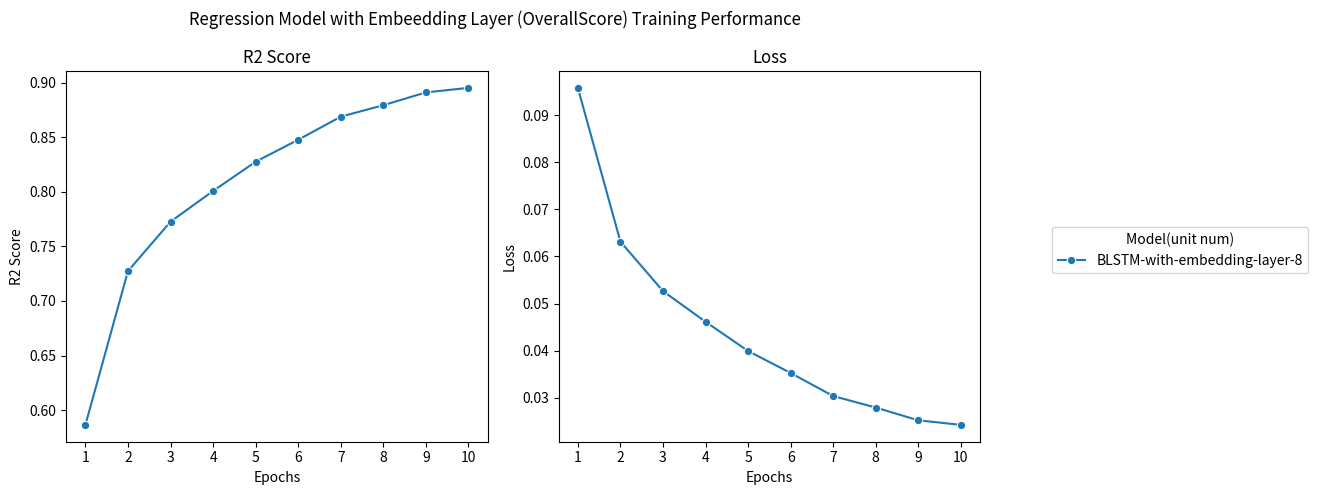

The testing MSE is: [0.06069758]
The testing R^2 is: [0.73997231]
The average training time of the model is: [51.95140918]


In [60]:
# Draw line chart for the training performance of the models accorss epochs
df_token_os_r2 = convert_train_result_to_df(data_list=[blstm_token_os_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_os_loss = convert_train_result_to_df(data_list=[blstm_token_os_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_os_r2, df_token_os_loss], title="Regression Model with Embeedding Layer (OverallScore) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_os_test_mse}")
print(f"The testing R^2 is: {blstm_token_os_test_r2}")
print(f"The average training time of the model is: {blstm_token_os_traintime}")

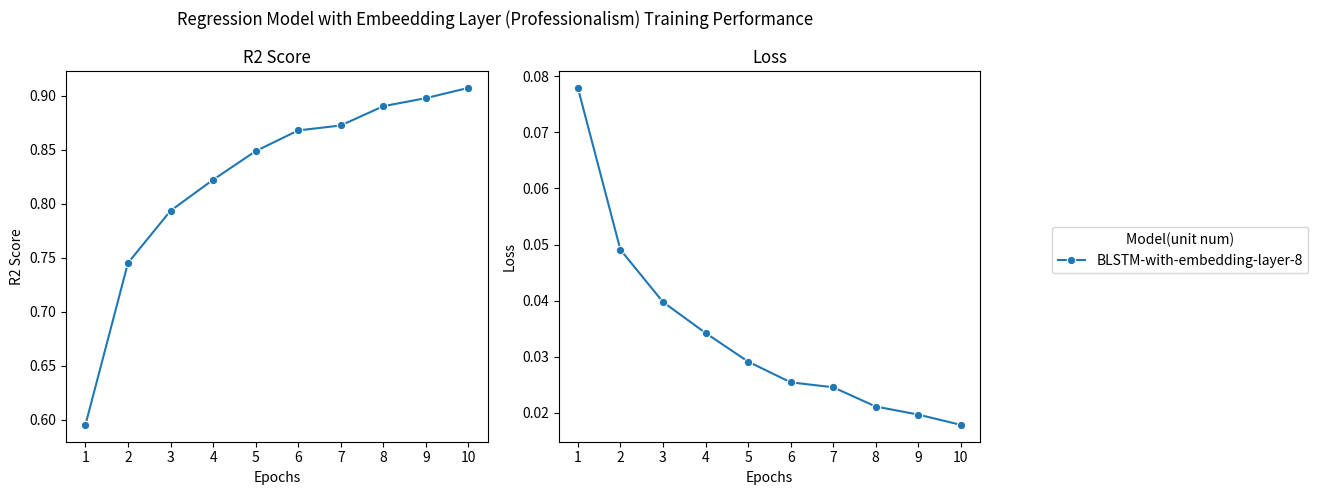

The testing MSE is: [0.04837117]
The testing R^2 is: [0.74834089]
The average training time of the model is: [52.4542551]


In [61]:
# Draw line chart for the training performance of the models accorss epochs
df_token_pro_r2 = convert_train_result_to_df(data_list=[blstm_token_pro_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_pro_loss = convert_train_result_to_df(data_list=[blstm_token_pro_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_pro_r2, df_token_pro_loss], title="Regression Model with Embeedding Layer (Professionalism) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_pro_test_mse}")
print(f"The testing R^2 is: {blstm_token_pro_test_r2}")
print(f"The average training time of the model is: {blstm_token_pro_traintime}")

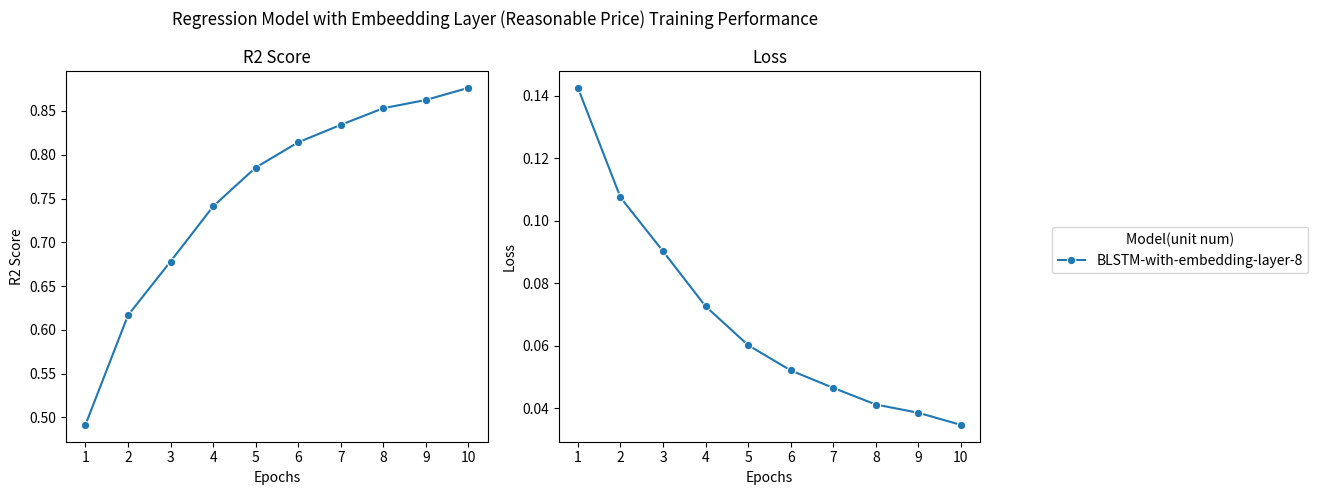

The testing MSE is: [0.1334927]
The testing R^2 is: [0.52981766]
The average training time of the model is: [51.75874869]


In [62]:
# Draw line chart for the training performance of the models accorss epochs
df_token_rp_r2 = convert_train_result_to_df(data_list=[blstm_token_rp_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_rp_loss = convert_train_result_to_df(data_list=[blstm_token_rp_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_rp_r2, df_token_rp_loss], title="Regression Model with Embeedding Layer (Reasonable Price) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_rp_test_mse}")
print(f"The testing R^2 is: {blstm_token_rp_test_r2}")
print(f"The average training time of the model is: {blstm_token_rp_traintime}")

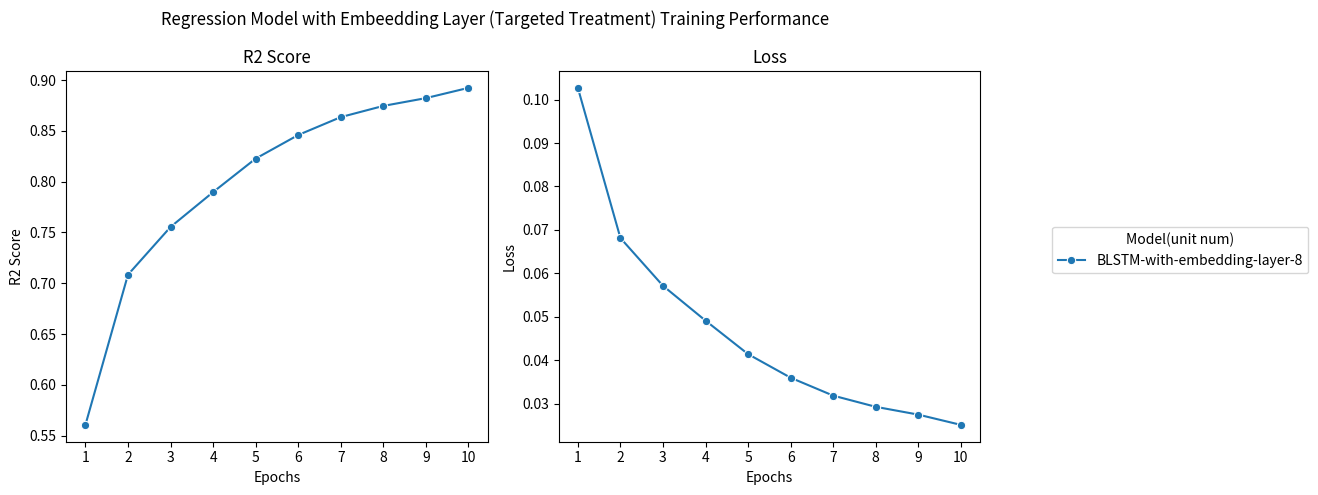

The testing MSE is: [0.07253626]
The testing R^2 is: [0.69129788]
The average training time of the model is: [51.62352316]


In [63]:
# Draw line chart for the training performance of the models accorss epochs
df_token_tt_r2 = convert_train_result_to_df(data_list=[blstm_token_tt_r2], model_names= model_names, unit_nums=unit_nums_list)
df_token_tt_loss = convert_train_result_to_df(data_list=[blstm_token_tt_loss], model_names=model_names, unit_nums=unit_nums_list)
draw_comparison_linechart(data_list=[df_token_tt_r2, df_token_tt_loss], title="Regression Model with Embeedding Layer (Targeted Treatment) Training Performance", subplot_titles=["R2 Score", "Loss"], x_label="Epochs", y_labels=["R2 Score", "Loss"], var_name="Model(unit num)")

# Draw line chart to compare the testing performace of the model
print(f"The testing MSE is: {blstm_token_tt_test_mse}")
print(f"The testing R^2 is: {blstm_token_tt_test_r2}")
print(f"The average training time of the model is: {blstm_token_tt_traintime}")

### Part 6 - Hyperparameter Tuning


*   In this part, we will use the Keras Tuner to tune the hyperparameter of the classification model
*   It is hoped that we could increase the F1 to above 0.85 in the test case consistently


In [64]:
### Define the classifier model building function
def classification_model_building(hp):

  model = tf.keras.Sequential();
  model.add(Input(shape=(128,)))


  """
  Tune the l2 regularization rate
  """
  hp_l2 = hp.Float("l2_regularizer", min_value=1e-4, max_value=1e-2, sampling="log")
  model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128,
            embeddings_regularizer=tf.keras.regularizers.l2(hp_l2)))

  """
  Tune the number of LSTM units in the first
  bidirectional LSTM layers.
  The dropout rate will also be tuned.
  """

  hp_lstm_units = hp.Choice("lstm_unit", values = [8, 16, 32, 64])
  hp_dropout = hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)

  model.add(
      Bidirectional(
          LSTM(
              units = hp_lstm_units,
              activation="tanh",
              recurrent_activation="sigmoid",
              return_sequences=False,
              kernel_regularizer=tf.keras.regularizers.l2(hp_l2)
            )
        )
    )

  """
  Tune the number of units in the feedforward layer
  Tune the dropout rate in the feedforward layer
  """

  # Dense layers with L2 regularization
  hp_dense_units = hp.Choice("dense_unit", values=[16, 32, 64])

  model.add(Dense(
      units=hp_dense_units,
      activation=None,
      use_bias=True,  # Changed to True
      kernel_regularizer=tf.keras.regularizers.l2(hp_l2)
  ))
  model.add(BatchNormalization())
  model.add(Activation("relu"))
  model.add(Dropout(hp_dropout))

  model.add(Dense(
      units=hp_dense_units // 2,
      activation=None,
      use_bias=True,  # Changed to True
      kernel_regularizer=tf.keras.regularizers.l2(hp_l2)
  ))
  model.add(BatchNormalization())
  model.add(Activation("relu"))
  model.add(Dropout(hp_dropout))


  model.add(Dense(3, activation='softmax'))

  """
  Tune the learning rate, decay steps, and gradient gradient clipping value
  """
  hp_learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
  hp_decay_steps = hp.Int("decay_steps", min_value=1000, max_value=5000, step=1000)
  hp_clip_value = hp.Float("clip_value", min_value=0.5, max_value=2.0, step=0.5)

  initial_learning_rate = hp_learning_rate
  decay_schedule = tf.keras.optimizers.schedules.CosineDecay(
      initial_learning_rate,
      decay_steps=hp_decay_steps
  )

  optimizer = tf.keras.optimizers.Adam(
      learning_rate=decay_schedule,
      clipvalue=hp_clip_value
  )

  model.compile(
      optimizer=optimizer,
      loss=tf.keras.losses.CategoricalCrossentropy(
          label_smoothing=0.1
      ),
      metrics=[
          tf.keras.metrics.CategoricalAccuracy(),
          tf.keras.metrics.F1Score(name="f1_score", average="macro")
      ],
  )

  return model

### Define the regression model building function
def regression_model_building(hp):

  model = tf.keras.Sequential();
  model.add(Input(shape=(128,)))
  model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128))

  """
  Tune the number of LSTM units in the first bidirectional LSTM layers.
  The dropout rate will also be tuned.
  """

  hp_lstm_units = hp.Choice("lstm_unit", values = [8, 16, 32, 64])
  hp_dropout = hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)
  model.add(
      Bidirectional(
          LSTM(
              units = hp_lstm_units,
              activation="tanh",
              recurrent_activation="sigmoid",
              return_sequences=False
            )
        )
    )

  """
  Tune the number of units in the feedforward layer
  """
  hp_dense_units = hp.Choice("dense_unit", values = [16,32,64])
  model.add(Dense(
      units = hp_dense_units,
      activation = None,
      use_bias = False,
  ))
  model.add(BatchNormalization())
  model.add(Activation("relu"))
  model.add(Dropout(hp_dropout))
  model.add(Dense(
      units = hp_dense_units // 2,
      activation = None,
      use_bias = False,
  ))
  model.add(BatchNormalization())
  model.add(Activation("relu"))
  model.add(Dropout(hp_dropout))
  model.add(Dense(1))

  """Tune the learning rate, decay steps and gradient clip value of the optimizer"""
  hp_learning_rate = hp.Float("learning_rate", min_value = 1e-4, max_value = 1e-2, sampling="log")
  hp_decay_steps = hp.Int("decay_step", min_value = 1000, max_value = 5000, step = 1000)
  hp_clip_value = hp.Float("clip_value", min_value=0.5, max_value=2.0, step=0.5)
  initial_learing_rate = hp_learning_rate
  decay_schedule = tf.keras.optimizers.schedules.CosineDecay(
      initial_learing_rate,
      decay_steps = hp_decay_steps,
  )

  optimizer = tf.keras.optimizers.Adam(
      learning_rate = decay_schedule,
      clipvalue = hp_clip_value,
  )
  model.compile(
      optimizer = optimizer,
      loss = tf.keras.losses.MeanSquaredError(),
      metrics=[
          tf.keras.metrics.MeanAbsoluteError(name = "mae"),
          tf.keras.metrics.R2Score(name = "r2_score"),
      ],
  )
  return model

In [65]:
# Compute class weight for one-hot-encoded classification target
def compute_onehot_class_weight(target: pd.DataFrame) -> dict:
  # Result in an column vector like [0, 1, 2], where each value refers to one class
  indices = np.argmax(target.values, axis = 1)

  #Compute the class weight
  class_weights = sklearn.utils.class_weight.compute_class_weight(
      class_weight = "balanced",
      classes = np.unique(indices),
      y = indices,
  )

  # Convert the class weight into dictionary
  return dict(enumerate(class_weights))

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)

In [66]:
### Function to search for the best hyperparameter using keras tuner
def model_tuning(
    X: np.ndarray,
    y: pd.DataFrame,
    model_builder: Callable[[kt.HyperParameters], tf.keras.Model],
    tuner_args: dict,
    searching_args: dict,
    classification: bool = True
) -> kt.Tuner:
  tuner = kt.Hyperband(
      hypermodel= model_builder,
      objective = tuner_args.get("objective", "val_loss"),
      max_epochs = tuner_args.get("max_epochs", 10),
      directory = tuner_args.get("directory", "keras_tuner"),
      project_name =tuner_args.get("project_name", "hp_tuning"),
      overwrite = tuner_args.get("overwrite", False),
  )
  if classification:
    data_class_weight = compute_onehot_class_weight(y[
        [
            "WorthRecommending_不予置評",
            "WorthRecommending_值得推介",
            "WorthRecommending_可以一試",
        ]
    ])
    tuner.search(
      X,
      y,
      epochs = tuner_args.get("epochs", 50),
      validation_split = tuner_args.get("validation_split", 0.2),
      callbacks=[stop_early],
      class_weight = data_class_weight,

    )
  else :
    tuner.search(
      X,
      y,
      epochs = tuner_args.get("epochs", 50),
      validation_split = tuner_args.get("validation_split", 0.2),
      callbacks=[stop_early],
    )

  return tuner

In [67]:
# wr_tuner_args = {
#     "objective": kt.Objective("val_f1_score", direction = "max"),
#     "max_epochs": 10,
#     "directory": "keras_tuner",
#     "project_name": "wr_tuning",
#     "overwrite": True,
# }
# wr_searching_args = {
#     "epochs": 10,
#     "validation_split": 0.2,
# }

# wr_tuner = model_tuning(
#     X_train_tokenized,
#     y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#     classification_model_building,
#     wr_tuner_args,
#     wr_searching_args,
#     True,
# )

In [68]:
regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 10,
    "directory": "keras_tuner",
    "project_name": "os_tuning",
    "overwrite": True,
}
regression_searching_args = {
    "epochs": 10,
    "validation_split": 0.2,
}

os_tuner = model_tuning(
    X_train_tokenized,
    y_train[["OverallScore"]],
    regression_model_building,
    regression_tuner_args,
    regression_searching_args,
    False,
)

Trial 30 Complete [00h 01m 04s]
val_r2_score: 0.7426968812942505

Best val_r2_score So Far: 0.7665185928344727
Total elapsed time: 00h 15m 21s


In [69]:
regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 10,
    "directory": "keras_tuner",
    "project_name": "pro_tuning",
    "overwrite": True,
}
pro_tuner = model_tuning(
    X_train_tokenized,
    y_train[["Professionalism"]],
    regression_model_building,
    regression_tuner_args,
    regression_searching_args,
    False,
)

Trial 30 Complete [00h 01m 05s]
val_r2_score: 0.7181798219680786

Best val_r2_score So Far: 0.7772093415260315
Total elapsed time: 00h 15m 27s


In [70]:
regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 10,
    "directory": "keras_tuner",
    "project_name": "rp_tuning",
    "overwrite": True,
}
rp_tuner = model_tuning(
    X_train_tokenized,
    y_train[["ReasonablePrice"]],
    regression_model_building,
    regression_tuner_args,
    regression_searching_args,
    False,
)

Trial 30 Complete [00h 00m 48s]
val_r2_score: 0.6133214235305786

Best val_r2_score So Far: 0.6269648671150208
Total elapsed time: 00h 14m 58s


In [71]:
regression_tuner_args = {
    "objective": kt.Objective("val_r2_score", direction = "max"),
    "max_epochs": 10,
    "directory": "keras_tuner",
    "project_name": "tt_tuning",
    "overwrite": True,
}

tt_tuner = model_tuning(
    X_train_tokenized,
    y_train[["TargetedTreatment"]],
    regression_model_building,
    regression_tuner_args,
    regression_searching_args,
    False,
)

Trial 30 Complete [00h 00m 53s]
val_r2_score: 0.7168766856193542

Best val_r2_score So Far: 0.7168766856193542
Total elapsed time: 00h 14m 48s


In [72]:
### Define a function that find the best epochs to train

def find_best_train_epochs(
    tuner : kt.Tuner,
    X_train: np.ndarray,
    y_train: pd.DataFrame,
    X_test: np.ndarray,
    y_test: pd.DataFrame,
    classification: bool = True):

  ### Train the models for 50 epochs and find the best training epochs
  best_hps = tuner.get_best_hyperparameters()[0]
  epoch_finding_model = tuner.hypermodel.build(best_hps)

  history = epoch_finding_model.fit(X_train, y_train,
                    epochs = 50, validation_split = 0.2)

  best_epoch = -1
  if classification is True:
    val_f1_per_epoch = history.history["val_f1_score"]
    best_epoch = val_f1_per_epoch.index(max(val_f1_per_epoch)) + 1
  else:
    val_r2_per_epoch = history.history['val_r2_score']
    best_epoch = val_r2_per_epoch.index(max(val_r2_per_epoch)) + 1

  ### Train the model with the best number of epoch found
  best_model = tuner.hypermodel.build(best_hps)
  best_model.fit(X_train, y_train, epochs = best_epoch, validation_split = 0.2)

  ### Evaluate the best model
  result = best_model.evaluate(X_test, y_test)

  ### return the model and the result
  return best_model, result

In [73]:
# wr_best_tuned_model, wr_test_result = find_best_train_epochs(
#     tuner = wr_tuner,
#     X_train = X_train_tokenized,
#     y_train = y_train[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#     X_test = X_test_tokenized,
#     y_test = y_test[["WorthRecommending_不予置評", "WorthRecommending_值得推介", "WorthRecommending_可以一試"]],
#     classification = True
# )

# print(f'Model loss value = {wr_test_result[0]}')
# print(f'Model categorical accuracy = {wr_test_result[1]}')
# print(f'Model R2 score = {wr_test_result[2]}')

In [74]:
os_best_tuned_model, os_test_result = find_best_train_epochs(
    tuner = os_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["OverallScore"]],
    X_test = X_test_tokenized,
    y_test = y_test[["OverallScore"]],
    classification = False
)
print(f'Model loss value = {os_test_result[0]}')
print(f'Model mean absolute error = {os_test_result[1]}')
print(f'Model R2 score = {os_test_result[2]}')

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.3737 - mae: 0.4667 - r2_score: -0.6226 - val_loss: 0.1099 - val_mae: 0.2957 - val_r2_score: 0.5294
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0817 - mae: 0.2195 - r2_score: 0.6448 - val_loss: 0.0652 - val_mae: 0.1902 - val_r2_score: 0.7207
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0651 - mae: 0.1901 - r2_score: 0.7178 - val_loss: 0.0602 - val_mae: 0.1740 - val_r2_score: 0.7421
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0540 - mae: 0.1760 - r2_score: 0.7681 - val_loss: 0.0594 - val_mae: 0.1693 - val_r2_score: 0.7457
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0563 - mae: 0.1794 - r2_score: 0.7562 - val_loss: 0.0595 - val_mae: 0.1688 - val_r2_score: 0.7452
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0543 - mae: 0.1765 - r2_score: 0.7636 - val_loss: 0.0595 - val_mae: 0.1689 - val_r2_score: 0.7451
Epoch 7/50
251/251 ━━━━━━━━━━━━━━

In [75]:
pro_best_tuned_model, pro_test_result = find_best_train_epochs(
    tuner = pro_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["Professionalism"]],
    X_test = X_test_tokenized,
    y_test = y_test[["Professionalism"]],
    classification = False
)
print(f'Model loss value = {pro_test_result[0]}')
print(f'Model mean absolute error = {pro_test_result[1]}')
print(f'Model R2 score = {pro_test_result[2]}')

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.3144 - mae: 0.3941 - r2_score: -0.6688 - val_loss: 0.0552 - val_mae: 0.1806 - val_r2_score: 0.7145
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0664 - mae: 0.1939 - r2_score: 0.6518 - val_loss: 0.0500 - val_mae: 0.1593 - val_r2_score: 0.7412
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0571 - mae: 0.1790 - r2_score: 0.7018 - val_loss: 0.0479 - val_mae: 0.1440 - val_r2_score: 0.7523
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0493 - mae: 0.1645 - r2_score: 0.7433 - val_loss: 0.0477 - val_mae: 0.1583 - val_r2_score: 0.7531
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0438 - mae: 0.1556 - r2_score: 0.7735 - val_loss: 0.0480 - val_mae: 0.1505 - val_r2_score: 0.7515
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0381 - mae: 0.1431 - r2_score: 0.8000 - val_loss: 0.0461 - val_mae: 0.1392 - val_r2_score: 0.7616
Epoch 7/50
251/251 ━━━━━━━━━━━━━

In [ ]:
rp_best_tuned_model, rp_test_result = find_best_train_epochs(
    tuner = rp_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["ReasonablePrice"]],
    X_test = X_test_tokenized,
    y_test = y_test[["ReasonablePrice"]],
    classification = False
)
print(f'Model loss value = {rp_test_result[0]}')
print(f'Model mean absolute error = {rp_test_result[1]}')
print(f'Model R2 score = {rp_test_result[2]}')

In [77]:
tt_best_tuned_model, tt_test_result = find_best_train_epochs(
    tuner = tt_tuner,
    X_train = X_train_tokenized,
    y_train = y_train[["TargetedTreatment"]],
    X_test = X_test_tokenized,
    y_test = y_test[["TargetedTreatment"]],
    classification = False
)
print(f'Model loss value = {tt_test_result[0]}')
print(f'Model mean absolute error = {tt_test_result[1]}')
print(f'Model R2 score = {tt_test_result[2]}')

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.4812 - mae: 0.5204 - r2_score: -1.0600 - val_loss: 0.1396 - val_mae: 0.3443 - val_r2_score: 0.4057
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1450 - mae: 0.2895 - r2_score: 0.3845 - val_loss: 0.0824 - val_mae: 0.2272 - val_r2_score: 0.6494
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0942 - mae: 0.2319 - r2_score: 0.5959 - val_loss: 0.0721 - val_mae: 0.1794 - val_r2_score: 0.6931
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0770 - mae: 0.2060 - r2_score: 0.6690 - val_loss: 0.0688 - val_mae: 0.1871 - val_r2_score: 0.7072
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0701 - mae: 0.1975 - r2_score: 0.6999 - val_loss: 0.0699 - val_mae: 0.1864 - val_r2_score: 0.7024
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0627 - mae: 0.1853 - r2_score: 0.7315 - val_loss: 0.0769 - val_mae: 0.1981 - val_r2_score: 0.6727
Epoch 7/50
251/251 ━━━━━━━━━━━━━